# Notebook 7

Work on the potential defined below

# Section 1

Familiarization with potential to see metastable states and potential shape

<Axes: title={'center': 'Potential V(x, y)'}, xlabel='x', ylabel='y'>

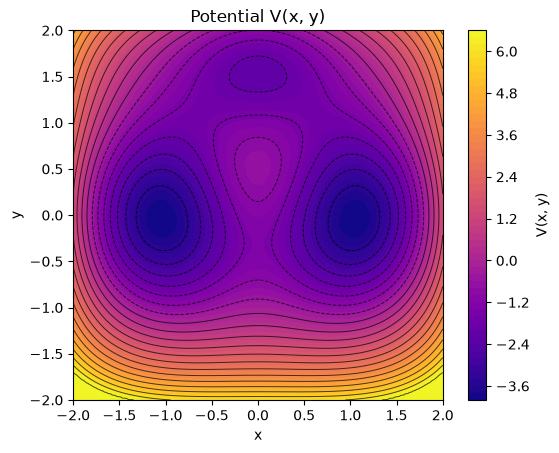

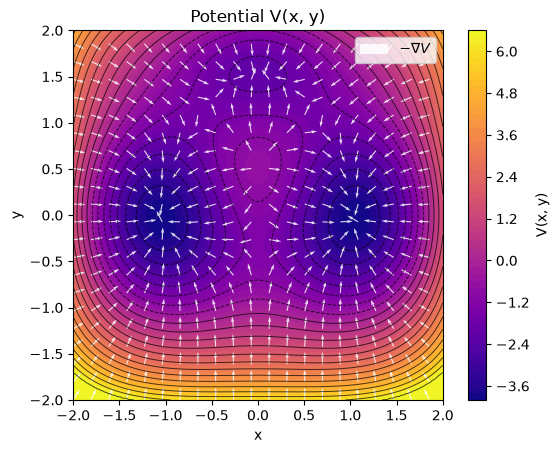

In [8]:
import numpy as np
from stage_escape.abp_abf.potential import Potential

def entropic_switch(x, y):
    tmp1 = x**2
    tmp2 = (y - 1 / 3)**2
    return 3 * np.exp(-tmp1) * (np.exp(-tmp2) - np.abs(np.exp(-(y - 5 / 3)**2))) - 5 * np.exp(-y**2) * (np.exp(-(x - 1)**2) + np.exp(-(x + 1)**2)) + 0.2 * tmp1**2 + 0.2 * tmp2**2

def grad_entropic_switch(x, y):

    tmp1 = np.exp(4*x)
    tmp2 = np.exp(-x**2 - 2*x - y**2 - 1)
    tmp3 = np.exp(-x**2)
    tmp4 = np.exp(-(y-1/3)**2)
    tmp5 = np.exp(-(y-5/3)**2)

    dx = 0.8*x**3 + 10*(tmp1*(x - 1) + x + 1)*tmp2 - 6*tmp3*x*(tmp4 - tmp5)

    dy = 10*(tmp1 + 1)*y*tmp2 + 3*tmp3*(2*tmp5*(y - 5/3) - 2*tmp4*(y - 1/3)) + 0.8*(y - 1/3)**3

    return np.array([dx, dy])

potential = Potential(2, lambda x: entropic_switch(x[0], x[1]), lambda x: grad_entropic_switch(x[0], x[1]))

potential.plot_potential()
potential.plot_potential(show_gradient=True)

# Section 2

Testing transition times between the two metastable states.

In [1]:
import numpy as np
from stage_escape.abp_abf.potential import Potential
from stage_escape.abp_abf.transition_detector import TransitionDetector
from stage_escape.abp_abf.abp_metadynamics import ABPMetaDynamics
from stage_escape.statistics import Statistics
from joblib import Parallel, delayed


def run_one_simulation():
    dt = 0.01
    potential = Potential(2, lambda x: entropic_switch(x[0], x[1]), lambda x: grad_entropic_switch(x[0], x[1]))


    abp = ABPMetaDynamics(num_steps=50, td=TransitionDetector(np.array([]), lambda x: -(x[0] - 1) ** 2 - x[1] ** 2, -1 / 4), delta_t=dt, dimension=2, D=1, initial_position=np.array([-1.0, 0.0]), b=potential)
    transition_time, simulation_time = abp.simulate()

    return transition_time, transition_time /simulation_time

Mean transition time: 6.148001521169431
Standard deviation of transition times: 5.456404465883329
Mean acceleration factor: 57.27057930432943
Standard deviation of acceleration factors: 137.691307417661


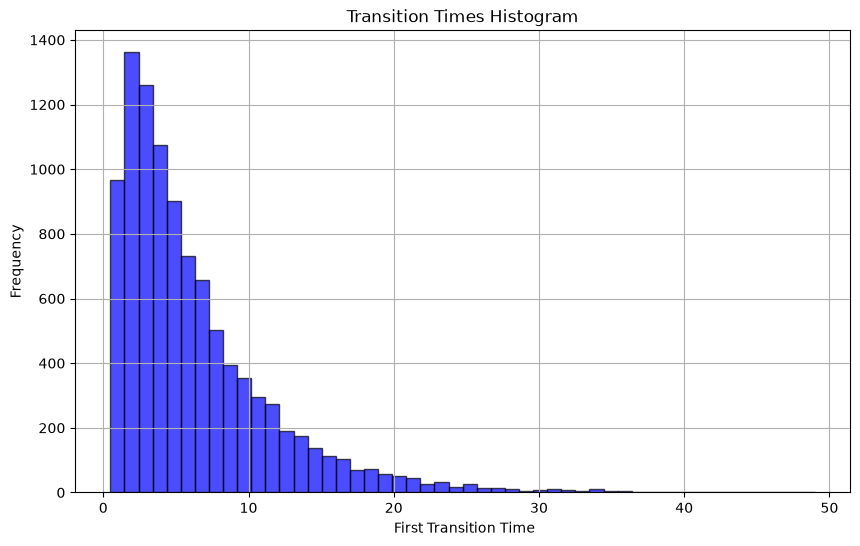

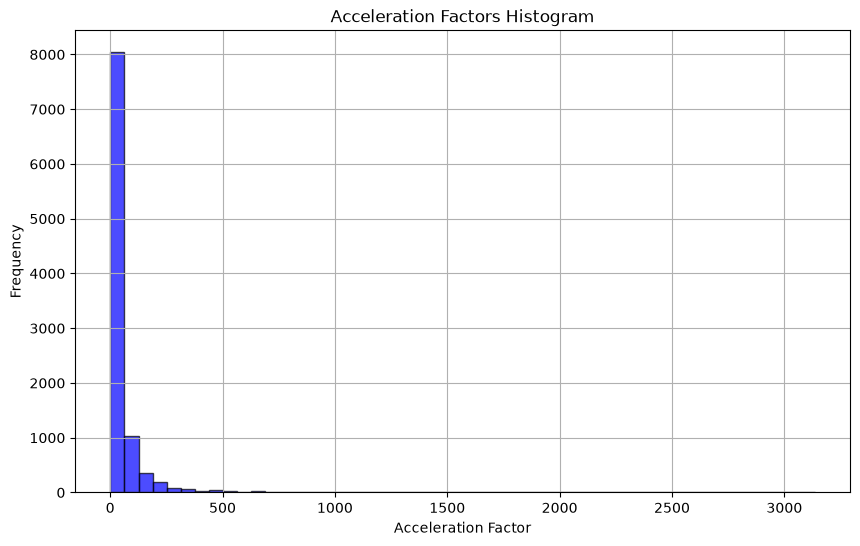

In [6]:
transition_times = []
acceleration_factors = []
exit_points = []

results = Parallel(n_jobs=-1)(
    delayed(run_one_simulation)()
    for _ in range(10000)
)

for transition_time, acc_factor in results:
    if transition_time is not None:
        transition_times.append(transition_time)
        acceleration_factors.append(acc_factor)

transition_times = np.array(transition_times)
acceleration_factors = np.array(acceleration_factors)

mean_transition_time = np.mean(transition_times)
mean_acceleration_factor = np.mean(acceleration_factors)

dev_transition_time = np.std(transition_times)
dev_acceleration_factor = np.std(acceleration_factors)

print(f"Mean transition time: {mean_transition_time}")
print(f"Standard deviation of transition times: {dev_transition_time}")

print(f"Mean acceleration factor: {mean_acceleration_factor}")
print(f"Standard deviation of acceleration factors: {dev_acceleration_factor}")

Statistics.plot_histogram(transition_times, bins=50, title="Transition Times Histogram", xlabel=" First Transition Time", ylabel="Frequency")
Statistics.plot_histogram(acceleration_factors, bins=50, title="Acceleration Factors Histogram", xlabel="Acceleration Factor", ylabel="Frequency")

Now we test on adapting an exponential distribution to the bottom part to get another estimate of the transition time mean

Estimated lambda for exponential distribution: 0.17983811024520588
Estimated mean transition time from exponential fit: 8.06055665084847


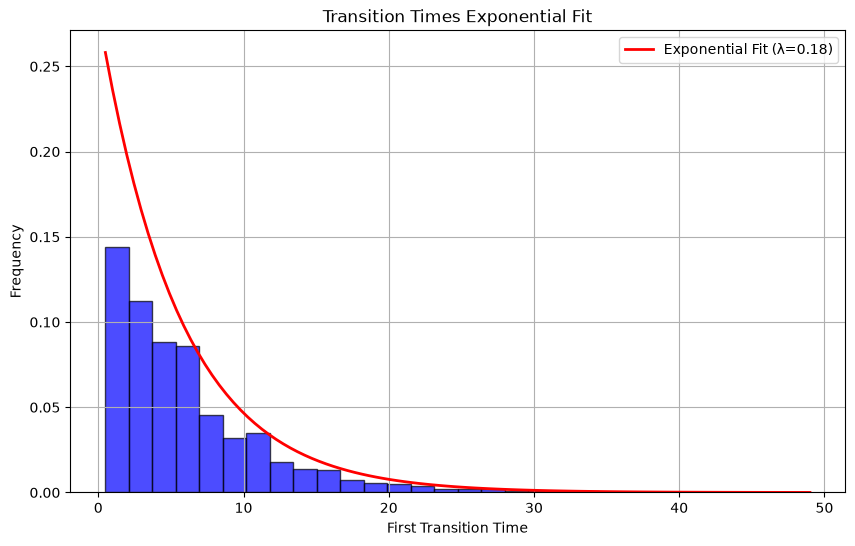

In [7]:
lbda = Statistics.adapt_exp_distribution(transition_times, t_min=2.5)

print(f"Estimated lambda for exponential distribution: {lbda}")
print(f"Estimated mean transition time from exponential fit: {1/lbda + 2.5}")
Statistics.plot_histogram_with_fit(transition_times, t_min=2.5, title="Transition Times Exponential Fit", xlabel="First Transition Time", ylabel="Frequency")

# Section 3

Hyperparameters exploration using normal estimations

In [3]:
import numpy as np
from stage_escape.abp_abf.potential import Potential
from stage_escape.abp_abf.transition_detector import TransitionDetector
from stage_escape.abp_abf.abp_metadynamics import ABPMetaDynamics
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from tqdm.notebook import tqdm


def run_one_simulation(num_steps, W, sigma):
    dt = 0.01
    potential = Potential(2, lambda x: entropic_switch(x[0], x[1]), lambda x: grad_entropic_switch(x[0], x[1]))


    abp = ABPMetaDynamics(num_steps=num_steps, td=TransitionDetector(np.array([]), lambda x: -(x[0] - 1) ** 2 - x[1] ** 2, -1 / 4), delta_t=dt, dimension=2, D=1, initial_position=np.array([-1.0, 0.0]), b=potential, W=W, sigma=sigma)
    transition_time, simulation_time = abp.simulate()

    return transition_time, transition_time /simulation_time, simulation_time / dt

W values:   0%|          | 0/20 [00:00<?, ?it/s]

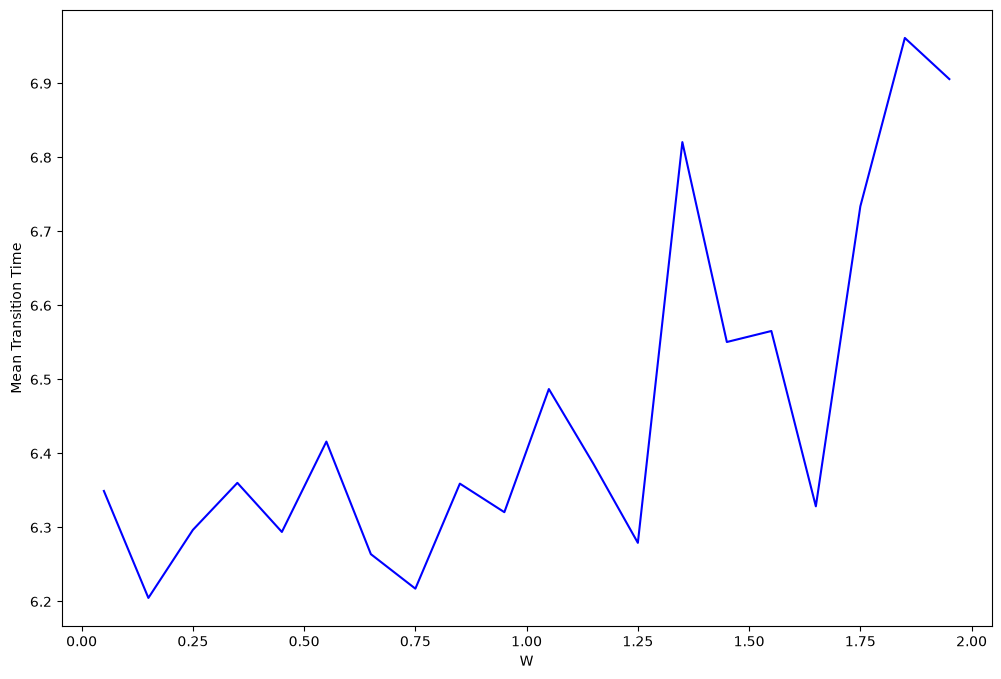

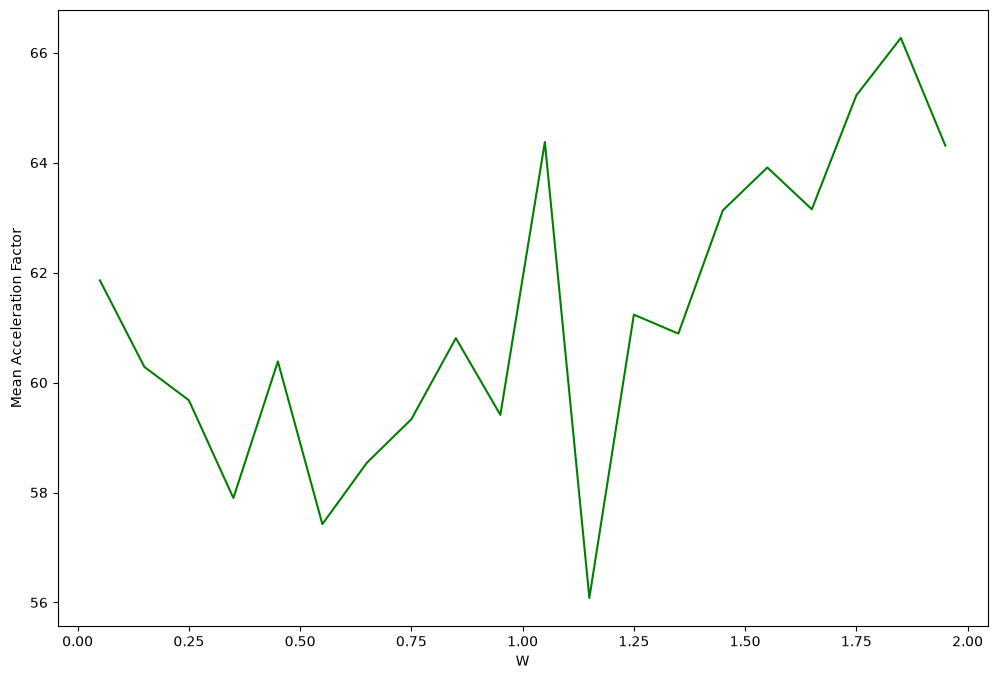

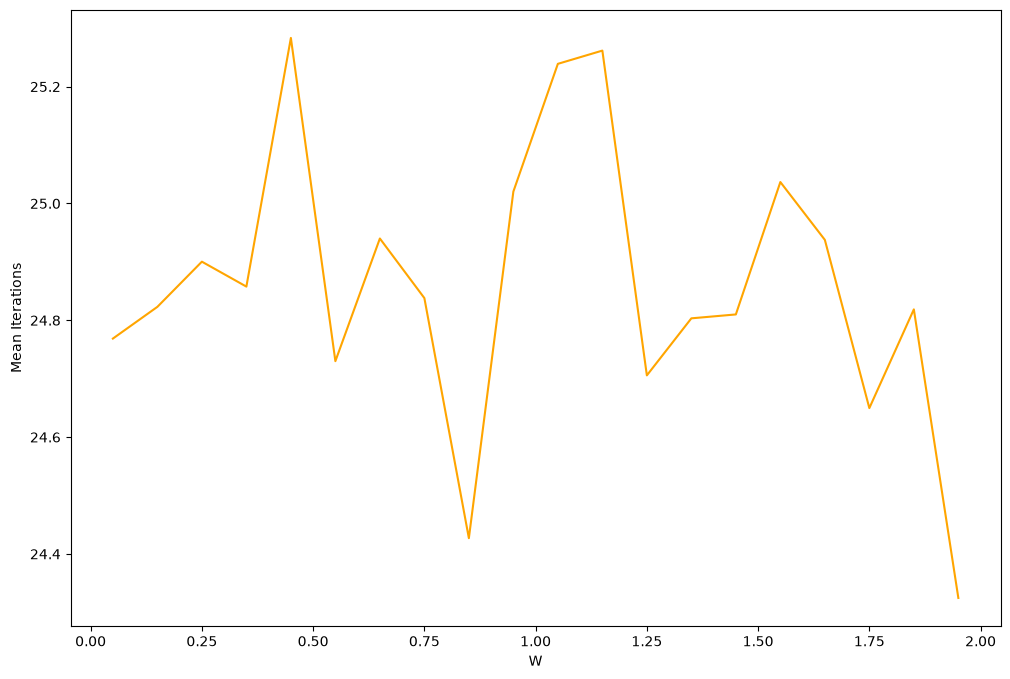

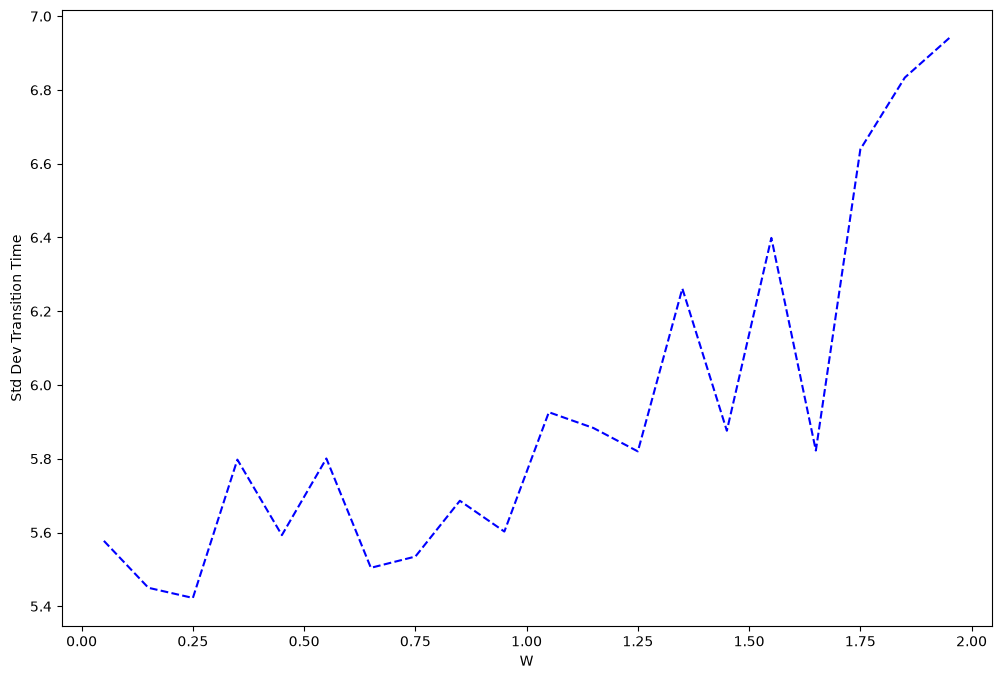

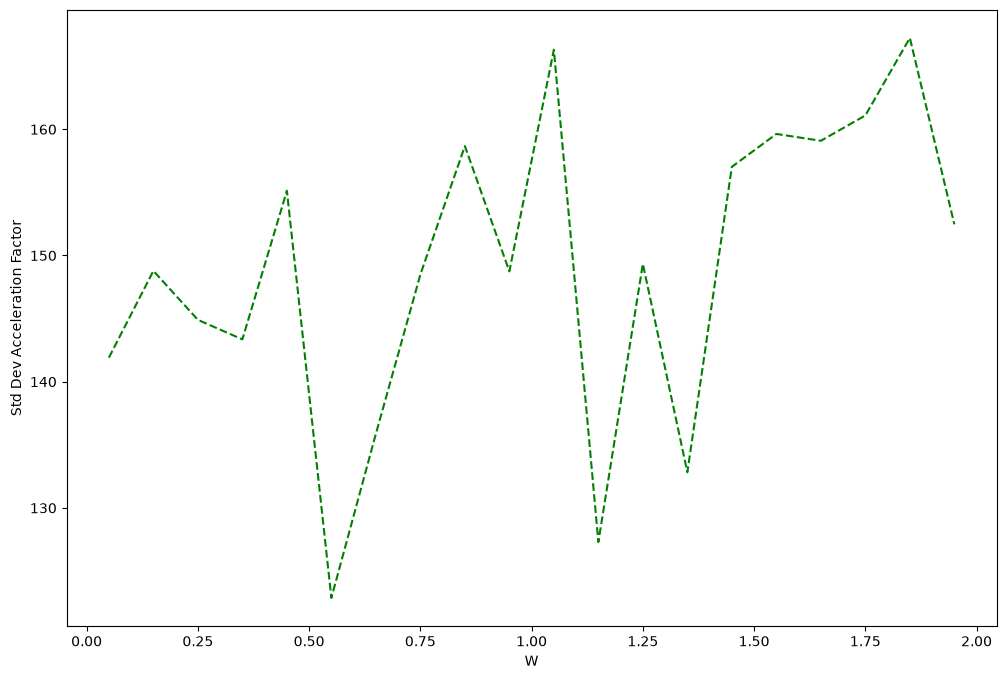

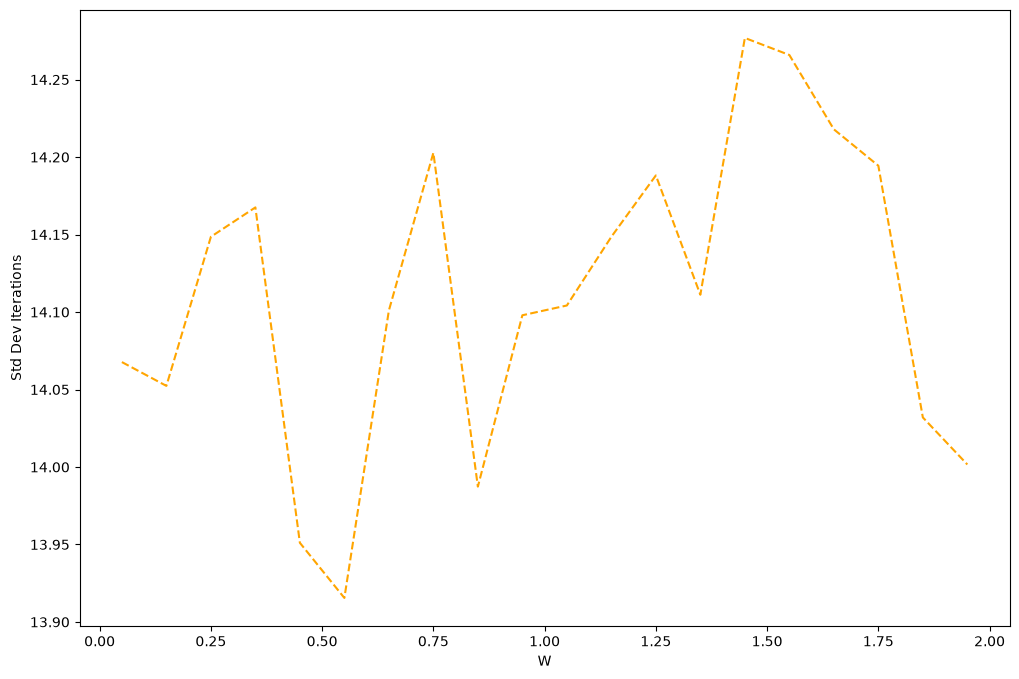

In [ ]:
W_axis = np.arange(0.05, 2.0, 0.1)
mean_transition_times = []
mean_acceleration_factors = []
mean_iterations = []
dev_transition_times = []
dev_acceleration_factors = []
dev_iterations = []

for W in tqdm(W_axis, desc="W values"):
    transition_times = []
    acceleration_factors = []
    iterations = []

    results = Parallel(n_jobs=-1)(
        delayed(run_one_simulation)(num_steps=50, W=W, sigma=0.1)
        for _ in range(3000)
    )

    for transition_time, acc_factor, simulation_time in results:
        if transition_time is not None:
            transition_times.append(transition_time)
            acceleration_factors.append(acc_factor)
            iterations.append(simulation_time)

    transition_times = np.array(transition_times)
    acceleration_factors = np.array(acceleration_factors)
    iterations = np.array(iterations)

    mean_transition_time = np.mean(transition_times)
    mean_acceleration_factor = np.mean(acceleration_factors)
    mean_iteration = np.mean(iterations)

    dev_transition_time = np.std(transition_times)
    dev_acceleration_factor = np.std(acceleration_factors)
    dev_iteration = np.std(iterations)

    mean_transition_times.append(mean_transition_time)
    mean_acceleration_factors.append(mean_acceleration_factor)
    mean_iterations.append(mean_iteration)
    dev_transition_times.append(dev_transition_time / np.sqrt(len(transition_times)))  # Standard error of the mean
    dev_acceleration_factors.append(dev_acceleration_factor / np.sqrt(len(acceleration_factors)))   # Standard error of the mean
    dev_iterations.append(dev_iteration / np.sqrt(len(iterations)))   # Standard error of the mean


plt.figure(figsize=(12, 8))
plt.xlabel('W')
plt.ylabel('Mean Transition Time')
plt.plot(W_axis, mean_transition_times, label='Mean Transition Time', color='blue')
plt.show()

plt.figure(figsize=(12, 8))
plt.xlabel('W')
plt.ylabel('Mean Acceleration Factor')
plt.plot(W_axis, mean_acceleration_factors, label='Mean Acceleration Factor', color='green')
plt.show()

plt.figure(figsize=(12, 8))
plt.xlabel('W')
plt.ylabel('Mean Iterations')
plt.plot(W_axis, mean_iterations, label='Mean Iterations', color='orange')
plt.show()

plt.figure(figsize=(12, 8))
plt.xlabel('W')
plt.ylabel('Std Dev Transition Time')
plt.plot(W_axis, dev_transition_times, label='Std Dev Transition Time', color='blue', linestyle='--')
plt.show()

plt.figure(figsize=(12, 8))
plt.xlabel('W')
plt.ylabel('Std Dev Acceleration Factor')
plt.plot(W_axis, dev_acceleration_factors, label='Std Dev Acceleration Factor', color='green', linestyle='--')
plt.show()

plt.figure(figsize=(12, 8))
plt.xlabel('W')
plt.ylabel('Std Dev Iterations')
plt.plot(W_axis, dev_iterations, label='Std Dev Iterations', color='orange', linestyle='--')
plt.show()

Sigma values:   0%|          | 0/20 [00:00<?, ?it/s]

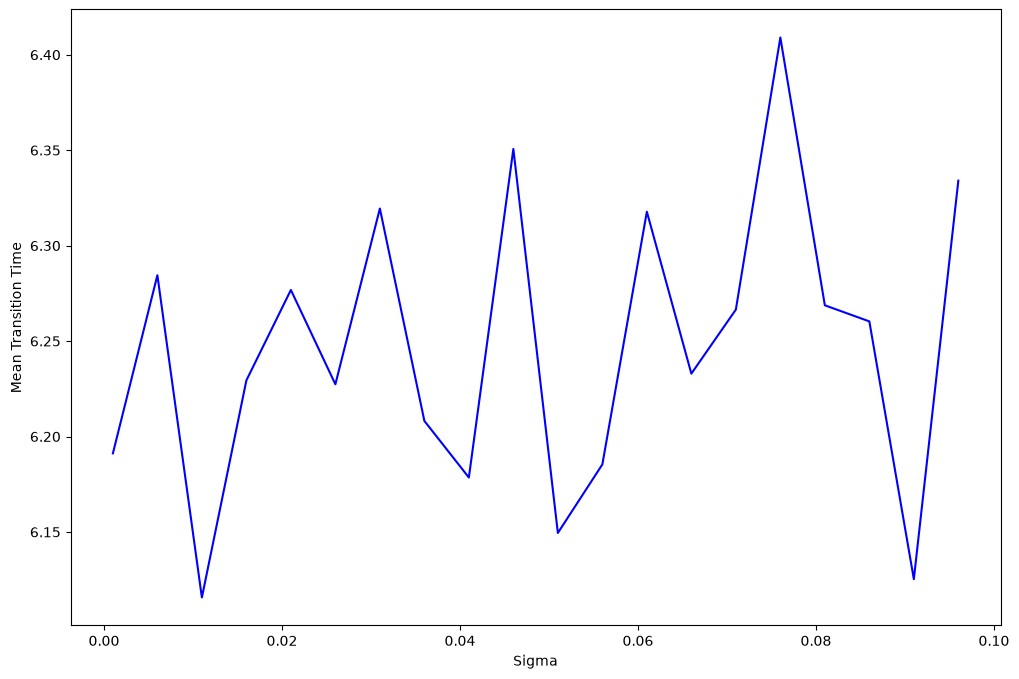

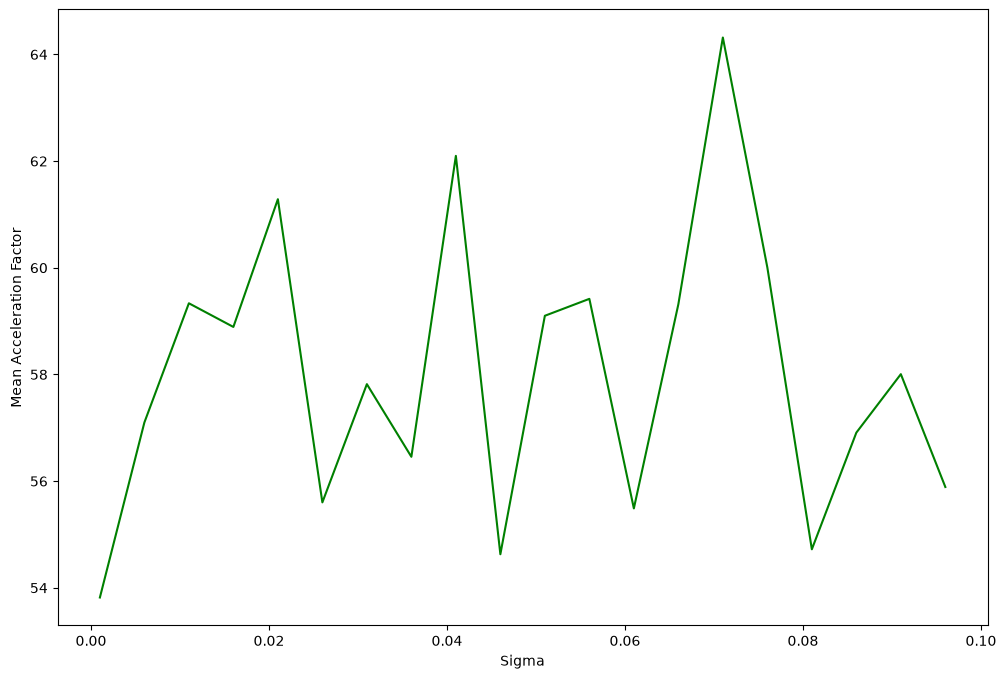

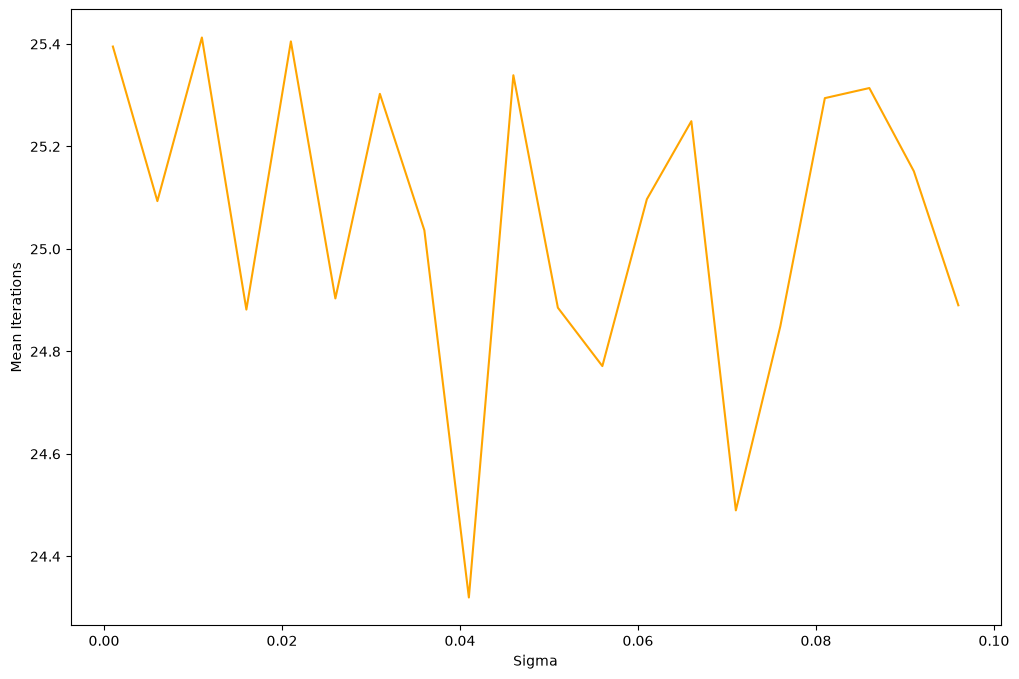

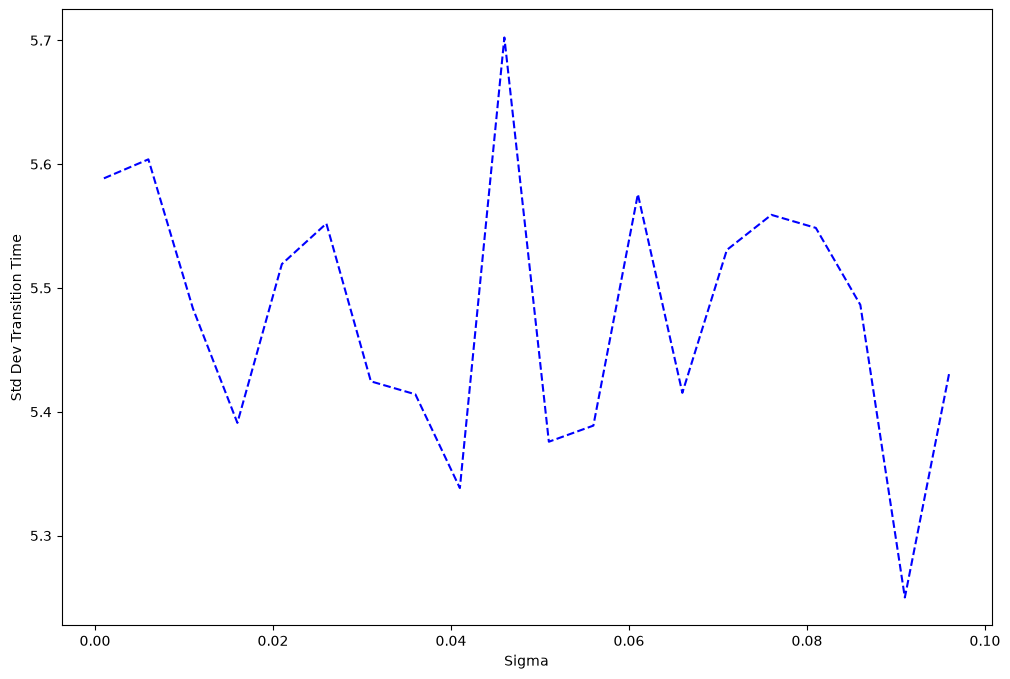

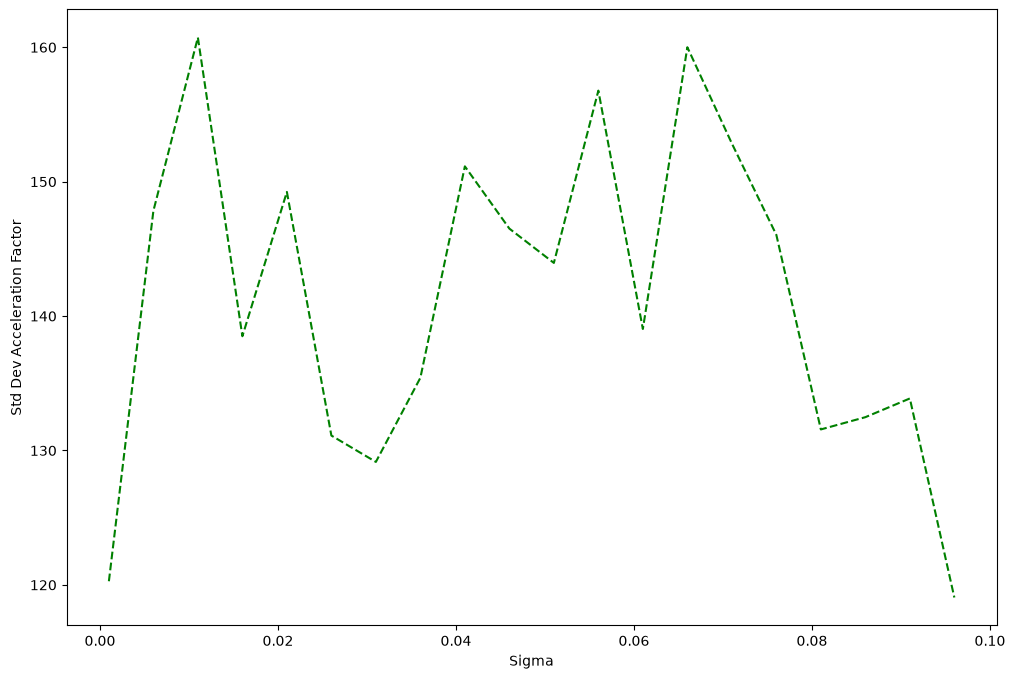

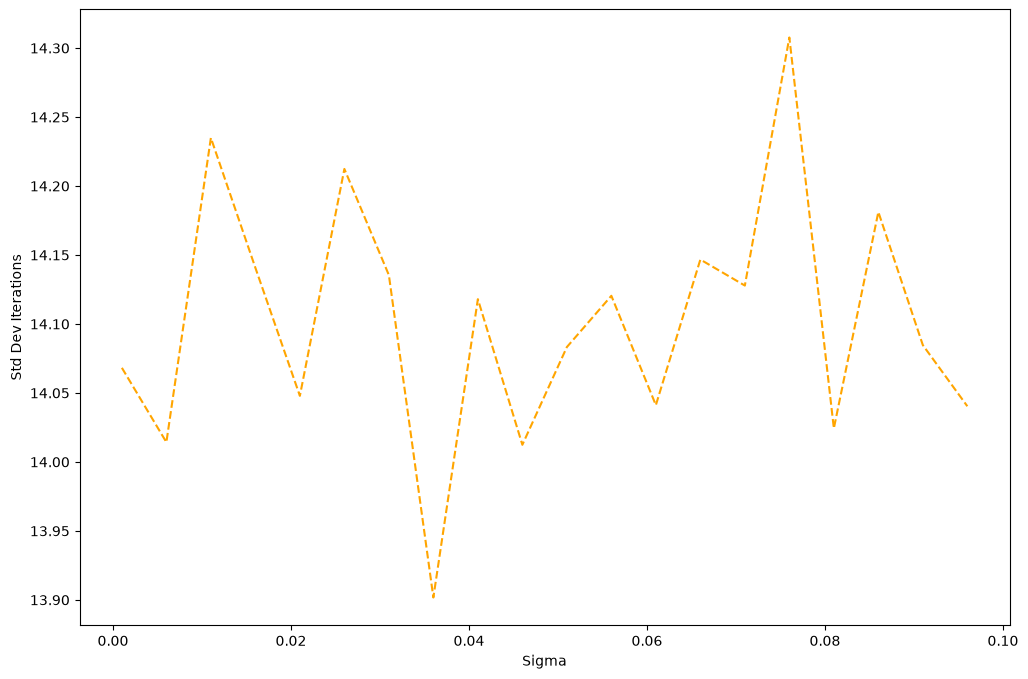

In [ ]:
sigma_axis = np.arange(0.001, 0.1, 0.005)
mean_transition_times = []
mean_acceleration_factors = []
mean_iterations = []
dev_transition_times = []
dev_acceleration_factors = []
dev_iterations = []

for sigma in tqdm(sigma_axis, desc="Sigma values"):
    transition_times = []
    acceleration_factors = []
    iterations = []

    results = Parallel(n_jobs=-1)(
        delayed(run_one_simulation)(num_steps=50, W=0.1, sigma=sigma)
        for _ in range(3000)
    )

    for transition_time, acc_factor, simulation_time in results:
        if transition_time is not None:
            transition_times.append(transition_time)
            acceleration_factors.append(acc_factor)
            iterations.append(simulation_time)

    transition_times = np.array(transition_times)
    acceleration_factors = np.array(acceleration_factors)
    iterations = np.array(iterations)

    mean_transition_time = np.mean(transition_times)
    mean_acceleration_factor = np.mean(acceleration_factors)
    mean_iteration = np.mean(iterations)

    dev_transition_time = np.std(transition_times)
    dev_acceleration_factor = np.std(acceleration_factors)
    dev_iteration = np.std(iterations)

    mean_transition_times.append(mean_transition_time)
    mean_acceleration_factors.append(mean_acceleration_factor)
    mean_iterations.append(mean_iteration)
    dev_transition_times.append(dev_transition_time / np.sqrt(len(transition_times)))  # Standard error of the mean
    dev_acceleration_factors.append(dev_acceleration_factor / np.sqrt(len(acceleration_factors)))   # Standard error of the mean
    dev_iterations.append(dev_iteration / np.sqrt(len(iterations)))   # Standard error of the mean


plt.figure(figsize=(12, 8))
plt.xlabel('Sigma')
plt.ylabel('Mean Transition Time')
plt.plot(sigma_axis, mean_transition_times, label='Mean Transition Time', color='blue')
plt.show()

plt.figure(figsize=(12, 8))
plt.xlabel('Sigma')
plt.ylabel('Mean Acceleration Factor')
plt.plot(sigma_axis, mean_acceleration_factors, label='Mean Acceleration Factor', color='green')
plt.show()

plt.figure(figsize=(12, 8))
plt.xlabel('Sigma')
plt.ylabel('Mean Iterations')
plt.plot(sigma_axis, mean_iterations, label='Mean Iterations', color='orange')
plt.show()

plt.figure(figsize=(12, 8))
plt.xlabel('Sigma')
plt.ylabel('Std Dev Transition Time')
plt.plot(sigma_axis, dev_transition_times, label='Std Dev Transition Time', color='blue', linestyle='--')
plt.show()

plt.figure(figsize=(12, 8))
plt.xlabel('Sigma')
plt.ylabel('Std Dev Acceleration Factor')
plt.plot(sigma_axis, dev_acceleration_factors, label='Std Dev Acceleration Factor', color='green', linestyle='--')
plt.show()

plt.figure(figsize=(12, 8))
plt.xlabel('Sigma')
plt.ylabel('Std Dev Iterations')
plt.plot(sigma_axis, dev_iterations, label='Std Dev Iterations', color='orange', linestyle='--')
plt.show()

Number of Steps:   0%|          | 0/18 [00:00<?, ?it/s]

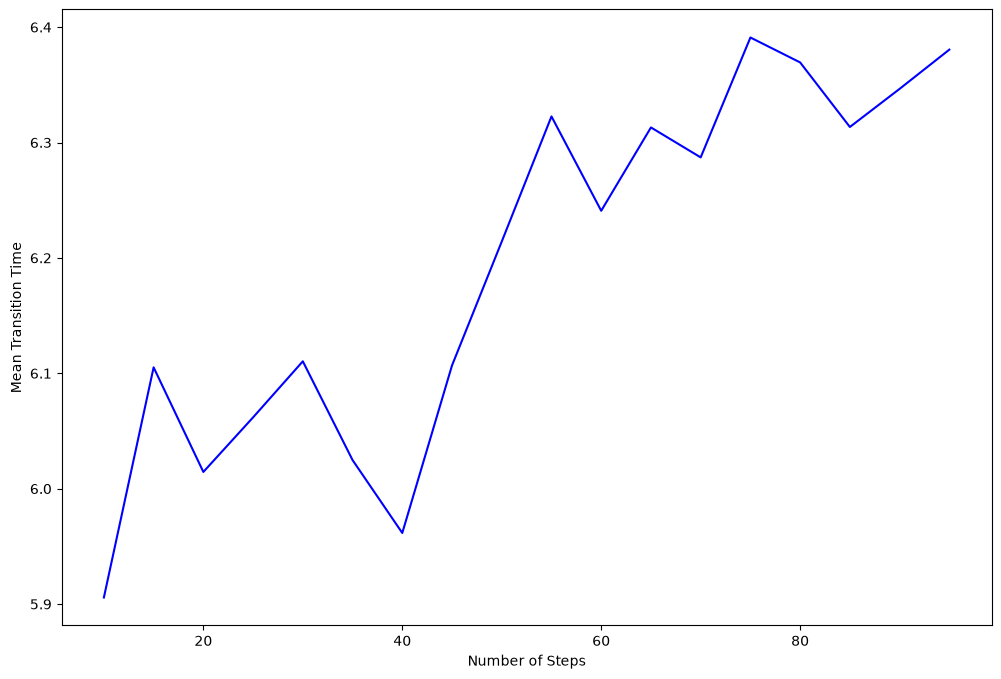

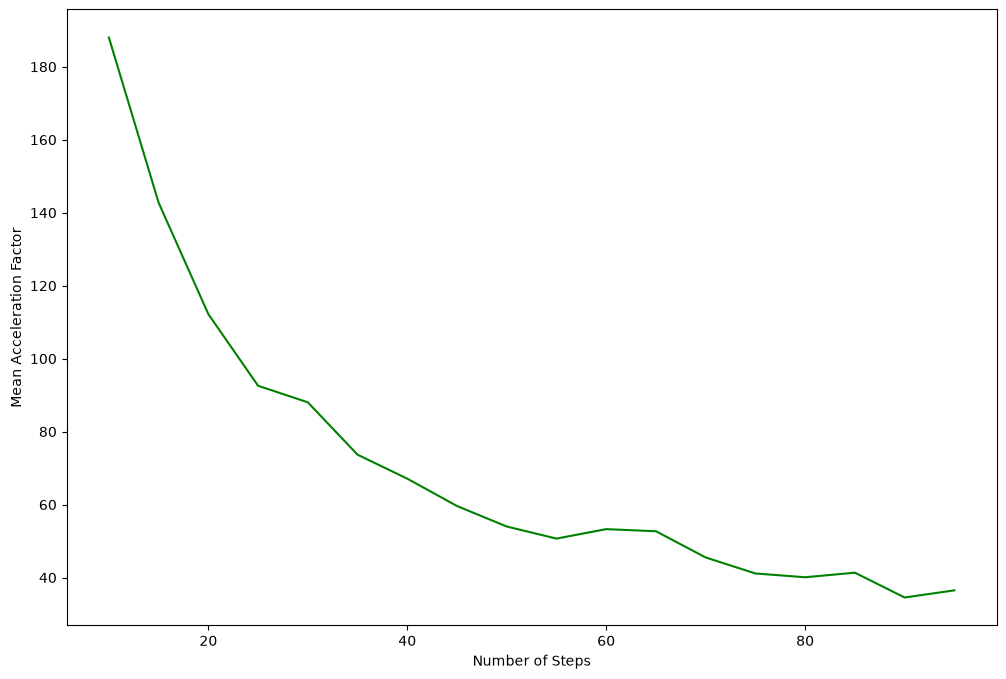

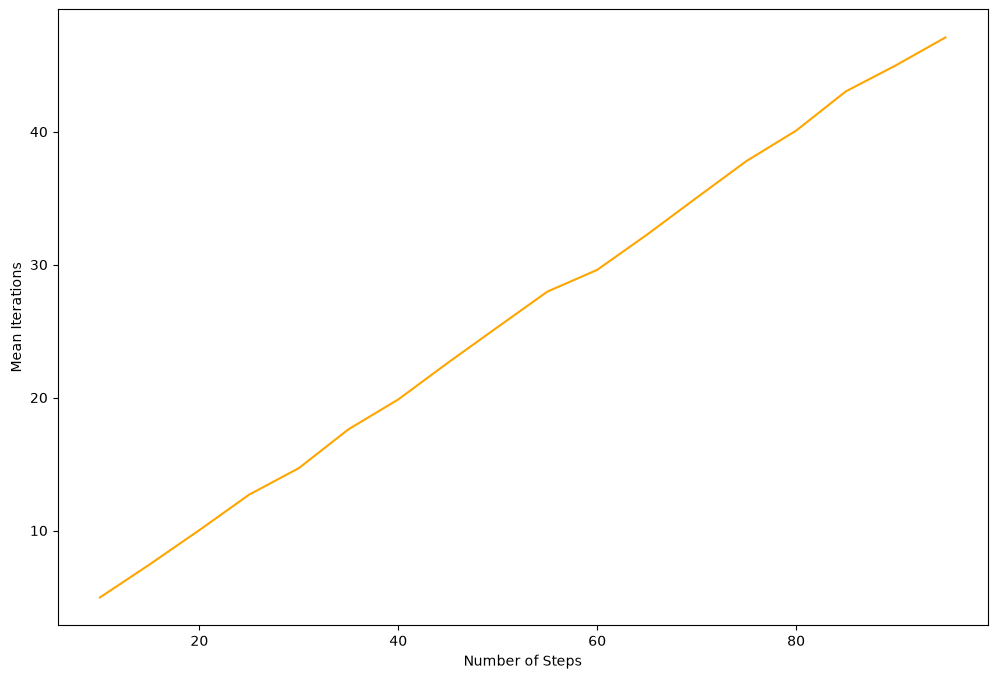

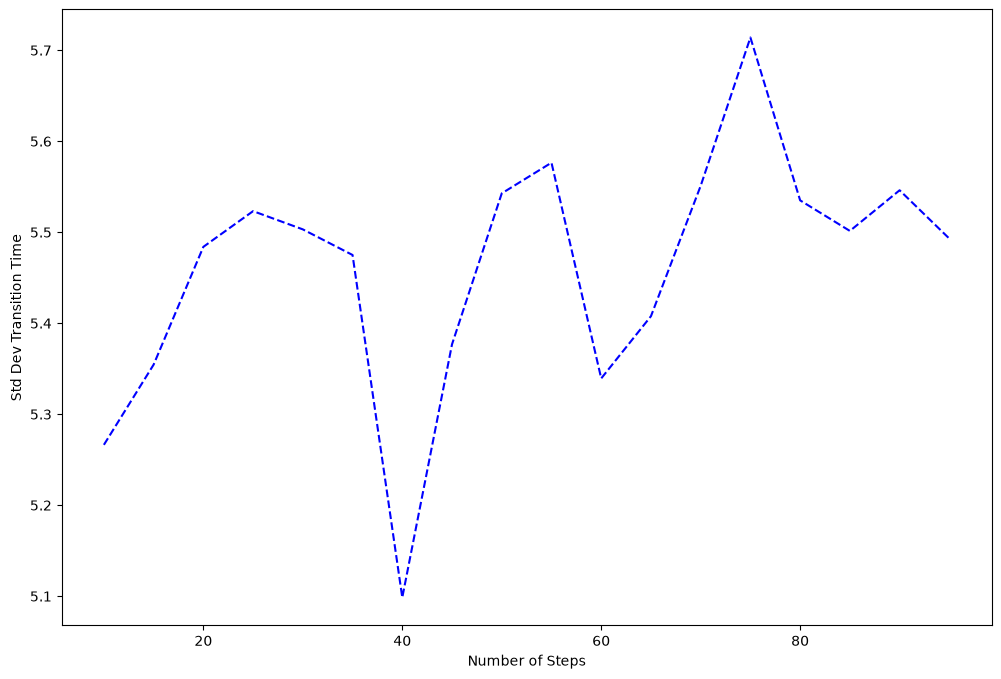

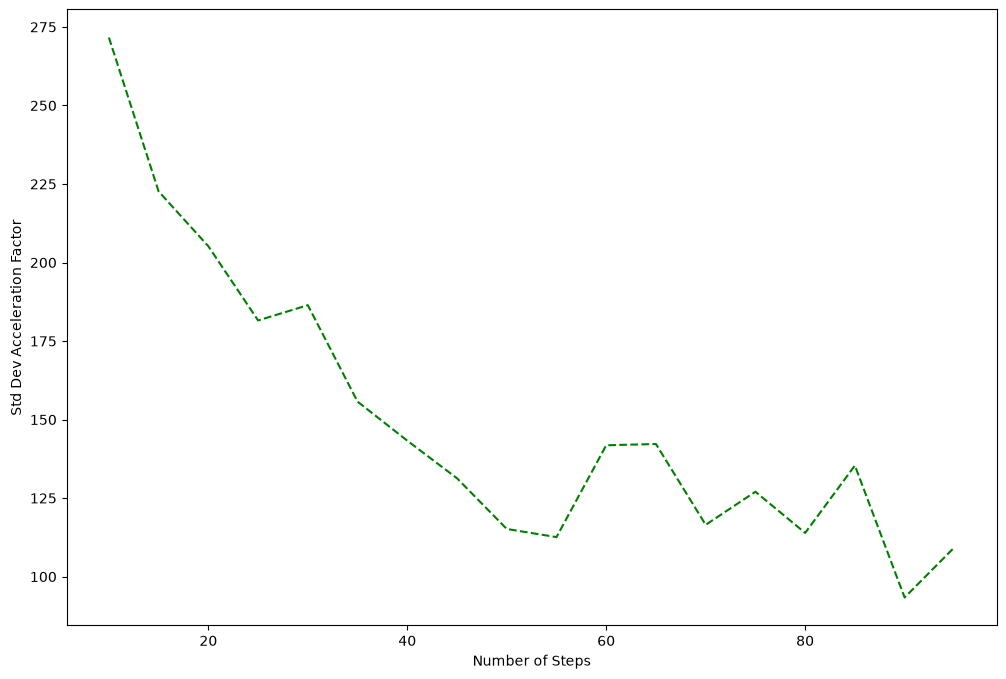

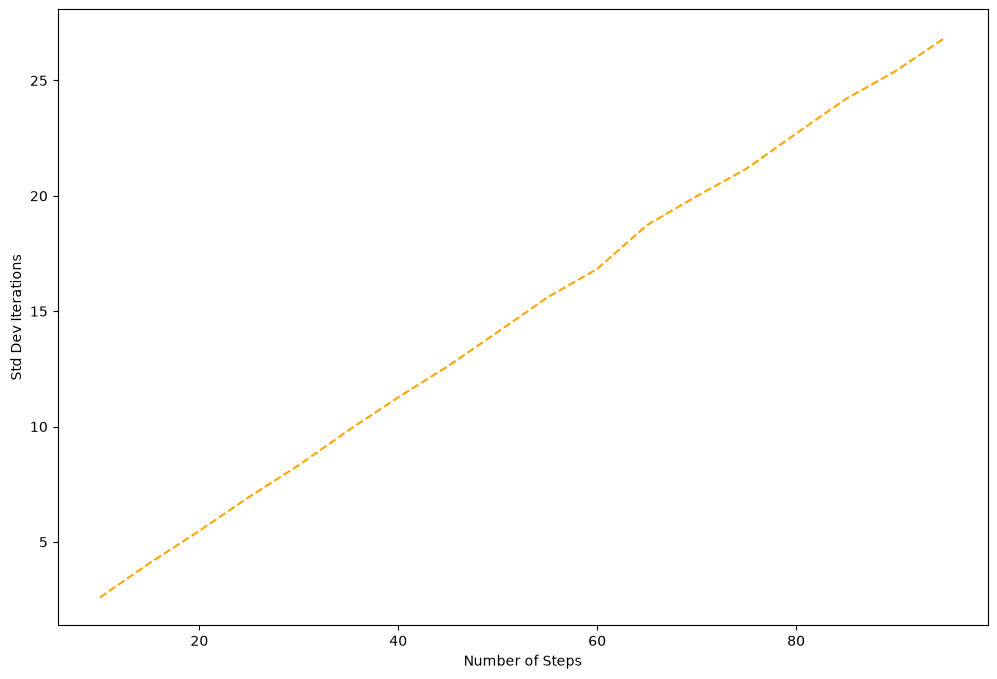

In [ ]:
num_steps_axis = np.arange(10, 100, 5)
mean_transition_times = []
mean_acceleration_factors = []
mean_iterations = []
dev_transition_times = []
dev_acceleration_factors = []
dev_iterations = []

for num_steps in tqdm(num_steps_axis, desc="Number of Steps"):
    transition_times = []
    acceleration_factors = []
    iterations = []

    results = Parallel(n_jobs=-1)(
        delayed(run_one_simulation)(num_steps=num_steps, W=0.1, sigma=0.01)
        for _ in range(3000)
    )

    for transition_time, acc_factor, simulation_time in results:
        if transition_time is not None:
            transition_times.append(transition_time)
            acceleration_factors.append(acc_factor)
            iterations.append(simulation_time)

    transition_times = np.array(transition_times)
    acceleration_factors = np.array(acceleration_factors)
    iterations = np.array(iterations)

    mean_transition_time = np.mean(transition_times)
    mean_acceleration_factor = np.mean(acceleration_factors)
    mean_iteration = np.mean(iterations)

    dev_transition_time = np.std(transition_times)
    dev_acceleration_factor = np.std(acceleration_factors)
    dev_iteration = np.std(iterations)

    mean_transition_times.append(mean_transition_time)
    mean_acceleration_factors.append(mean_acceleration_factor)
    mean_iterations.append(mean_iteration)
    dev_transition_times.append(dev_transition_time / np.sqrt(len(transition_times)))  # Standard error of the mean
    dev_acceleration_factors.append(dev_acceleration_factor / np.sqrt(len(acceleration_factors)))   # Standard error of the mean
    dev_iterations.append(dev_iteration / np.sqrt(len(iterations)))   # Standard error of the mean


plt.figure(figsize=(12, 8))
plt.xlabel('Number of Steps')
plt.ylabel('Mean Transition Time')
plt.plot(num_steps_axis, mean_transition_times, label='Mean Transition Time', color='blue')
plt.show()

plt.figure(figsize=(12, 8))
plt.xlabel('Number of Steps')
plt.ylabel('Mean Acceleration Factor')
plt.plot(num_steps_axis, mean_acceleration_factors, label='Mean Acceleration Factor', color='green')
plt.show()

plt.figure(figsize=(12, 8))
plt.xlabel('Number of Steps')
plt.ylabel('Mean Iterations')
plt.plot(num_steps_axis, mean_iterations, label='Mean Iterations', color='orange')
plt.show()

plt.figure(figsize=(12, 8))
plt.xlabel('Number of Steps')
plt.ylabel('Std Dev Transition Time')
plt.plot(num_steps_axis, dev_transition_times, label='Std Dev Transition Time', color='blue', linestyle='--')
plt.show()

plt.figure(figsize=(12, 8))
plt.xlabel('Number of Steps')
plt.ylabel('Std Dev Acceleration Factor')
plt.plot(num_steps_axis, dev_acceleration_factors, label='Std Dev Acceleration Factor', color='green', linestyle='--')
plt.show()

plt.figure(figsize=(12, 8))
plt.xlabel('Number of Steps')
plt.ylabel('Std Dev Iterations')
plt.plot(num_steps_axis, dev_iterations, label='Std Dev Iterations', color='orange', linestyle='--')
plt.show()

## Section 4

Further exploration on the number of steps' influence over the results obtained

In [ ]:
import time
import numpy as np
from stage_escape.abp_abf.potential import Potential
from stage_escape.abp_abf.transition_detector import TransitionDetector
from stage_escape.abp_abf.abp_metadynamics import ABPMetaDynamics
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from tqdm.notebook import tqdm


def run_one_simulation(num_steps, W, sigma):
    dt = 0.01
    potential = Potential(2, lambda x: entropic_switch(x[0], x[1]), lambda x: grad_entropic_switch(x[0], x[1]))

    start = time.perf_counter()
    abp = ABPMetaDynamics(num_steps=num_steps, td=TransitionDetector(np.array([]), lambda x: -(x[0] - 1) ** 2 - x[1] ** 2, -1 / 4), delta_t=dt, dimension=2, D=1, initial_position=np.array([-1.0, 0.0]), b=potential, W=W, sigma=sigma)
    transition_time, simulation_time = abp.simulate()
    end = time.perf_counter()

    return transition_time, transition_time /simulation_time, simulation_time / dt, end - start

Number of Steps:   0%|          | 0/48 [00:00<?, ?it/s]

----------- MEAN ANALYSIS -----------


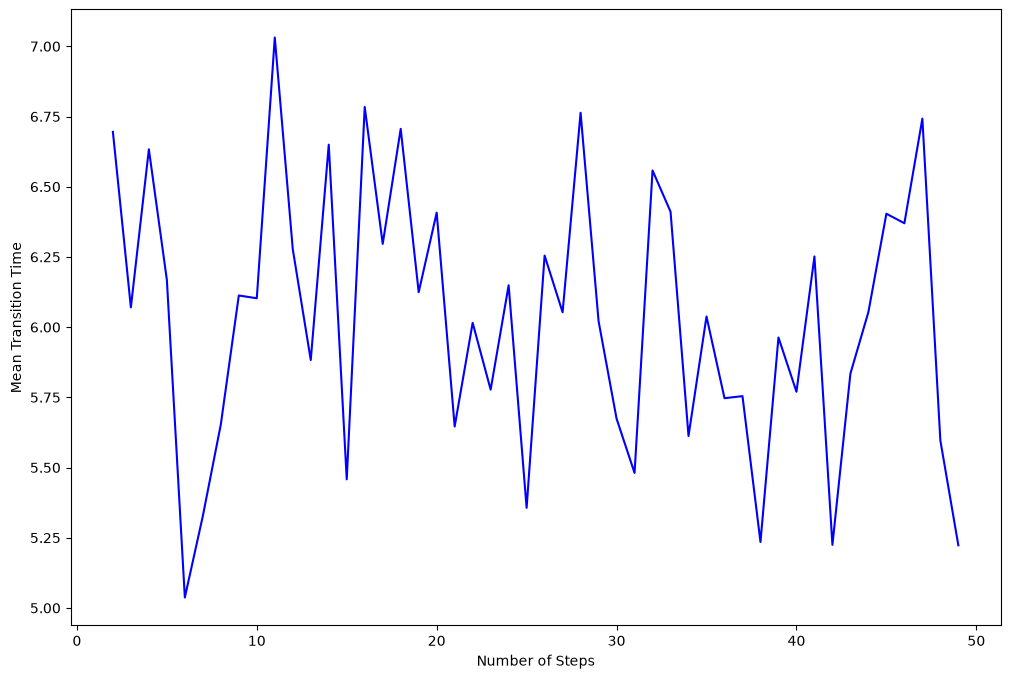

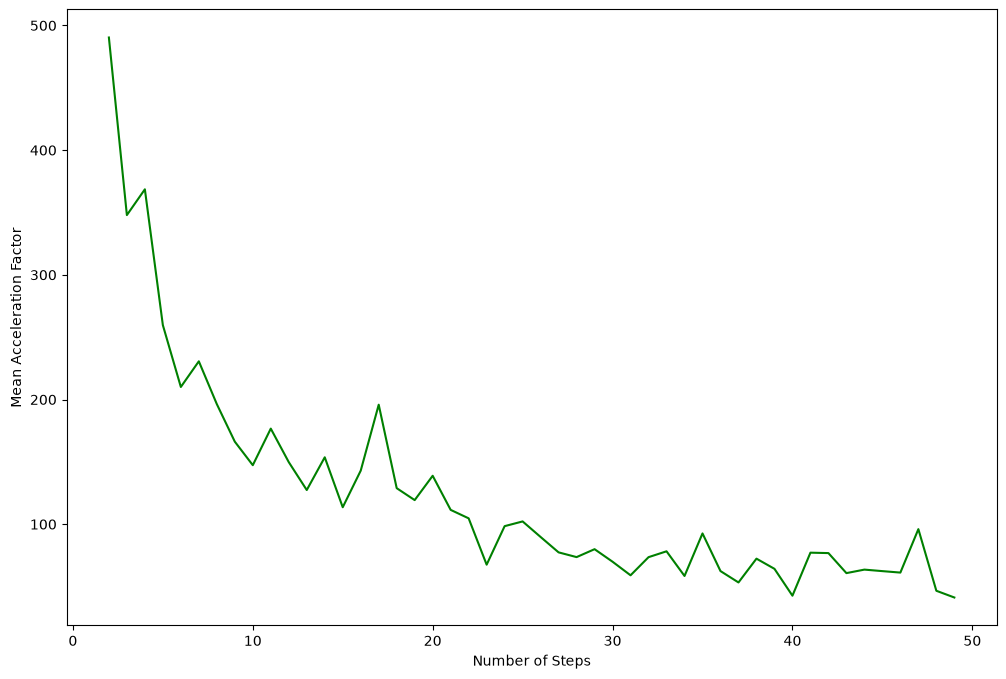

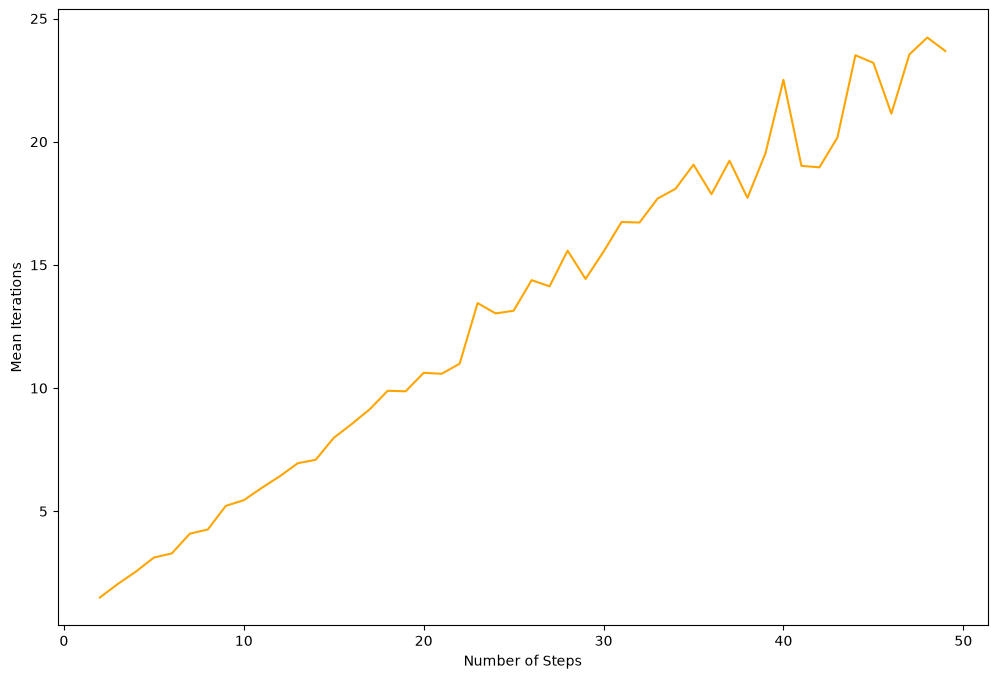

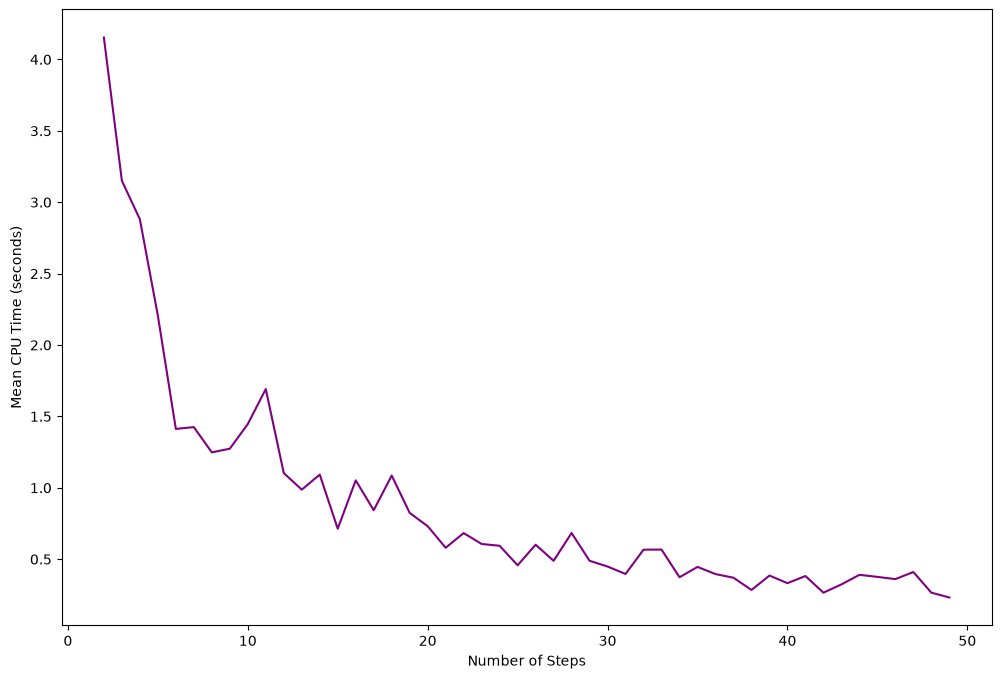

----------- STANDARD DEVIATION ANALYSIS -----------


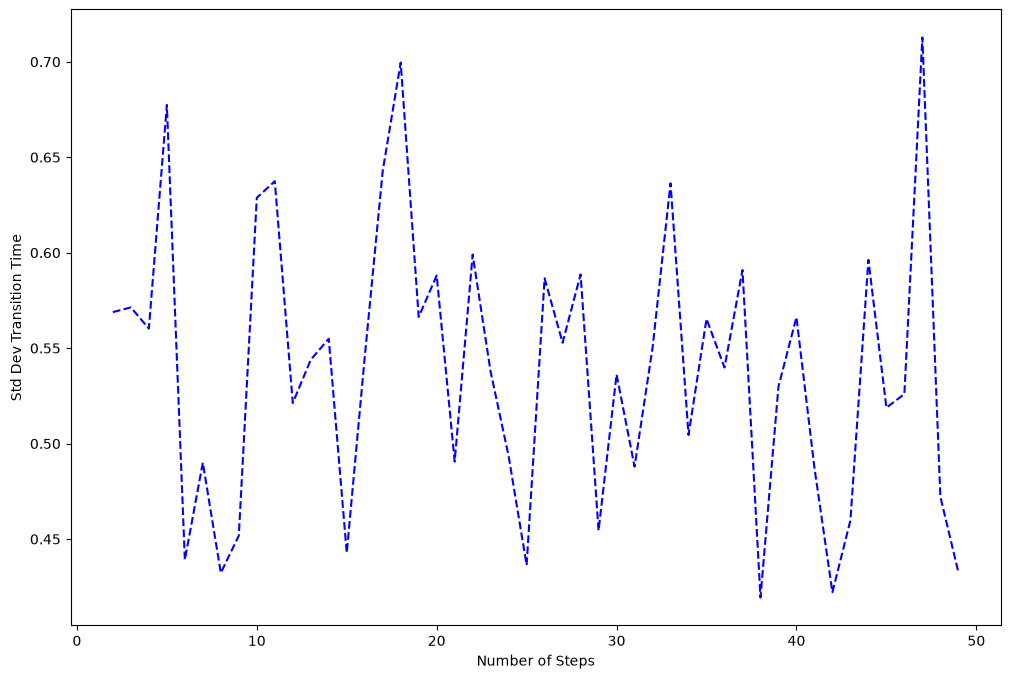

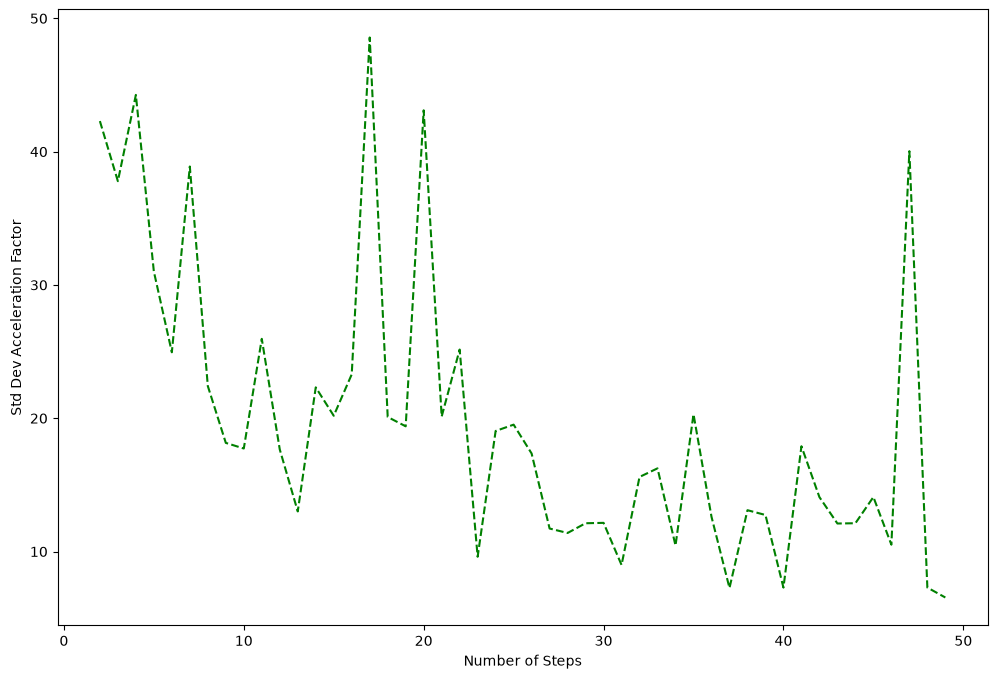

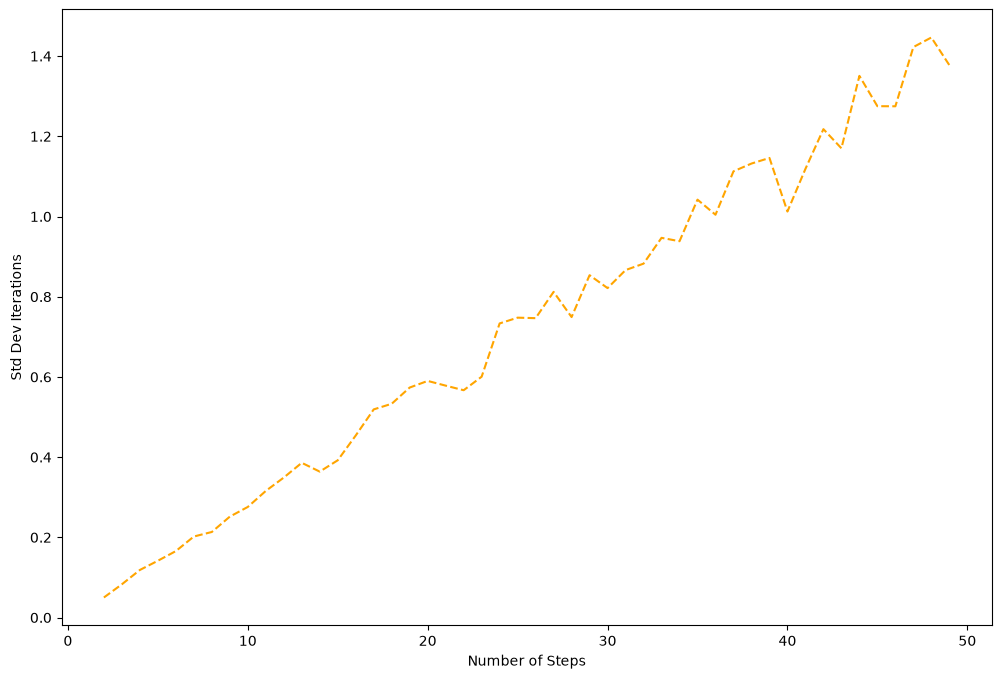

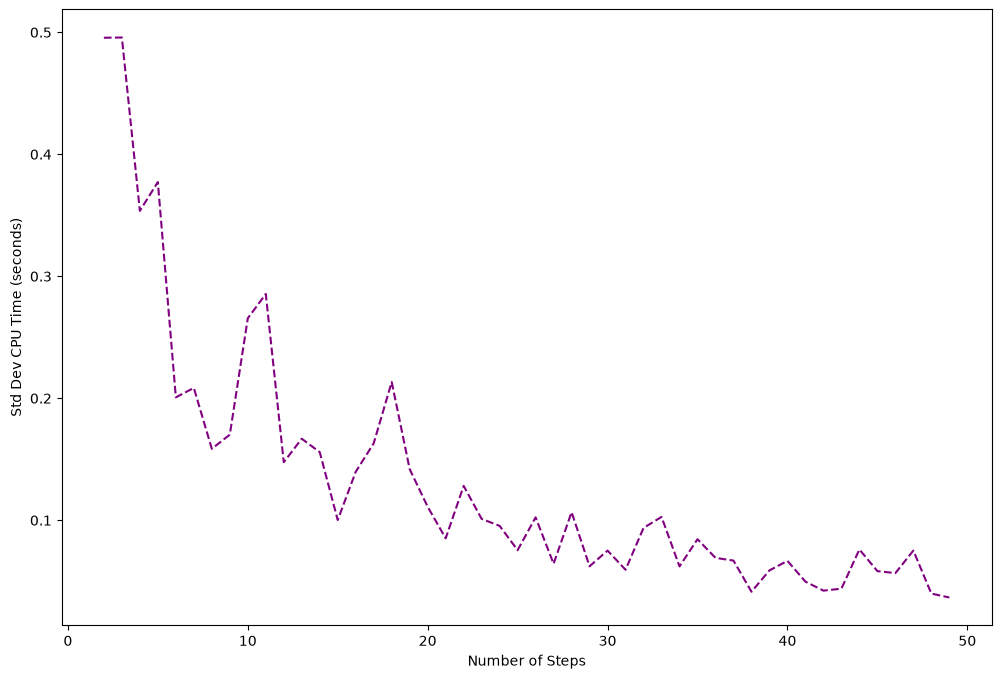

In [ ]:
num_steps_axis = np.arange(2, 50, 1)
mean_transition_times = []
mean_acceleration_factors = []
mean_iterations = []
mean_cpu_times = []
dev_transition_times = []
dev_acceleration_factors = []
dev_iterations = []
dev_cpu_times = []

for num_steps in tqdm(num_steps_axis, desc="Number of Steps"):
    transition_times = []
    acceleration_factors = []
    iterations = []
    cpu_times = []

    results = Parallel(n_jobs=-1)(
        delayed(run_one_simulation)(num_steps=num_steps, W=0.5, sigma=0.05)
        for _ in range(100)
    )

    for transition_time, acc_factor, simulation_time, cpu_time in results:
        if transition_time is not None:
            transition_times.append(transition_time)
            acceleration_factors.append(acc_factor)
            iterations.append(simulation_time)
            cpu_times.append(cpu_time)

    transition_times = np.array(transition_times)
    acceleration_factors = np.array(acceleration_factors)
    iterations = np.array(iterations)
    cpu_times = np.array(cpu_times)

    mean_transition_time = np.mean(transition_times)
    mean_acceleration_factor = np.mean(acceleration_factors)
    mean_iteration = np.mean(iterations)
    mean_cpu_time = np.mean(cpu_times)

    dev_transition_time = np.std(transition_times)
    dev_acceleration_factor = np.std(acceleration_factors)
    dev_iteration = np.std(iterations)
    dev_cpu_time = np.std(cpu_times)

    mean_transition_times.append(mean_transition_time)
    mean_acceleration_factors.append(mean_acceleration_factor)
    mean_iterations.append(mean_iteration)
    mean_cpu_times.append(mean_cpu_time)
    dev_transition_times.append(dev_transition_time / np.sqrt(len(transition_times)))  # Standard error of the mean
    dev_acceleration_factors.append(dev_acceleration_factor / np.sqrt(len(acceleration_factors)))   # Standard error of the mean
    dev_iterations.append(dev_iteration / np.sqrt(len(iterations)))   # Standard error of the mean
    dev_cpu_times.append(dev_cpu_time / np.sqrt(len(cpu_times)))   # Standard error of the mean

print('----------- MEAN ANALYSIS -----------')

plt.figure(figsize=(12, 8))
plt.xlabel('Number of Steps')
plt.ylabel('Mean Transition Time')
plt.plot(num_steps_axis, mean_transition_times, label='Mean Transition Time', color='blue')
plt.show()

plt.figure(figsize=(12, 8))
plt.xlabel('Number of Steps')
plt.ylabel('Mean Acceleration Factor')
plt.plot(num_steps_axis, mean_acceleration_factors, label='Mean Acceleration Factor', color='green')
plt.show()

plt.figure(figsize=(12, 8))
plt.xlabel('Number of Steps')
plt.ylabel('Mean Iterations')
plt.plot(num_steps_axis, mean_iterations, label='Mean Iterations', color='orange')
plt.show()

plt.figure(figsize=(12, 8))
plt.xlabel('Number of Steps')
plt.ylabel('Mean CPU Time (seconds)')
plt.plot(num_steps_axis, mean_cpu_times, label='Mean CPU Time', color='purple')
plt.show()

print('----------- STANDARD DEVIATION ANALYSIS -----------')

plt.figure(figsize=(12, 8))
plt.xlabel('Number of Steps')
plt.ylabel('Std Dev Transition Time')
plt.plot(num_steps_axis, dev_transition_times, label='Std Dev Transition Time', color='blue', linestyle='--')
plt.show()

plt.figure(figsize=(12, 8))
plt.xlabel('Number of Steps')
plt.ylabel('Std Dev Acceleration Factor')
plt.plot(num_steps_axis, dev_acceleration_factors, label='Std Dev Acceleration Factor', color='green', linestyle='--')
plt.show()

plt.figure(figsize=(12, 8))
plt.xlabel('Number of Steps')
plt.ylabel('Std Dev Iterations')
plt.plot(num_steps_axis, dev_iterations, label='Std Dev Iterations', color='orange', linestyle='--')
plt.show()

plt.figure(figsize=(12, 8))
plt.xlabel('Number of Steps')
plt.ylabel('Std Dev CPU Time (seconds)')
plt.plot(num_steps_axis, dev_cpu_times, label='Std Dev CPU Time', color='purple', linestyle='--')
plt.show()

In [34]:
import time
import numpy as np
from stage_escape.abp_abf.potential import Potential
from stage_escape.abp_abf.transition_detector import TransitionDetector
from stage_escape.abp_abf.abp_metadynamics import ABPMetaDynamics
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from tqdm.notebook import tqdm


def run_one_simulation(num_steps, W, sigma):
    dt = 0.01
    potential = Potential(2, lambda x: entropic_switch(x[0], x[1]), lambda x: grad_entropic_switch(x[0], x[1]))

    start = time.perf_counter()
    abp = ABPMetaDynamics(num_steps=num_steps, td=TransitionDetector(np.array([]), lambda x: -(x[0] - 1) ** 2 - x[1] ** 2, -1 / 4), delta_t=dt, dimension=2, D=0.01, initial_position=np.array([-1.0, 0.0]), b=potential, W=W, sigma=sigma)
    transition_time, simulation_time = abp.simulate()
    end = time.perf_counter()

    return transition_time, transition_time /simulation_time, simulation_time / dt, end - start

Number of Steps:   0%|          | 0/47 [00:00<?, ?it/s]

----------- MEAN ANALYSIS -----------


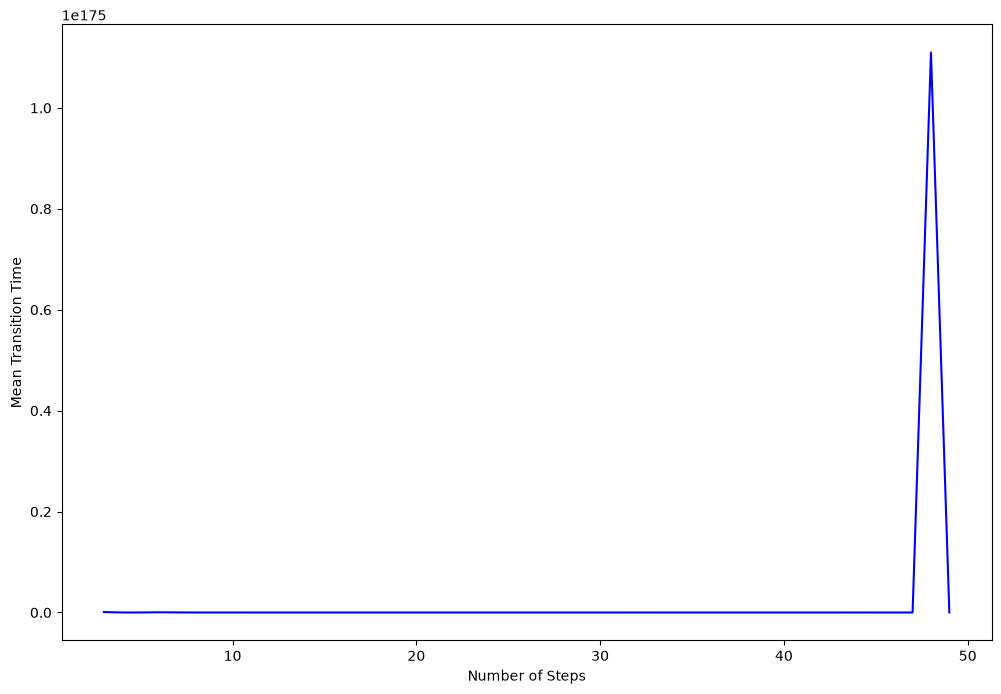

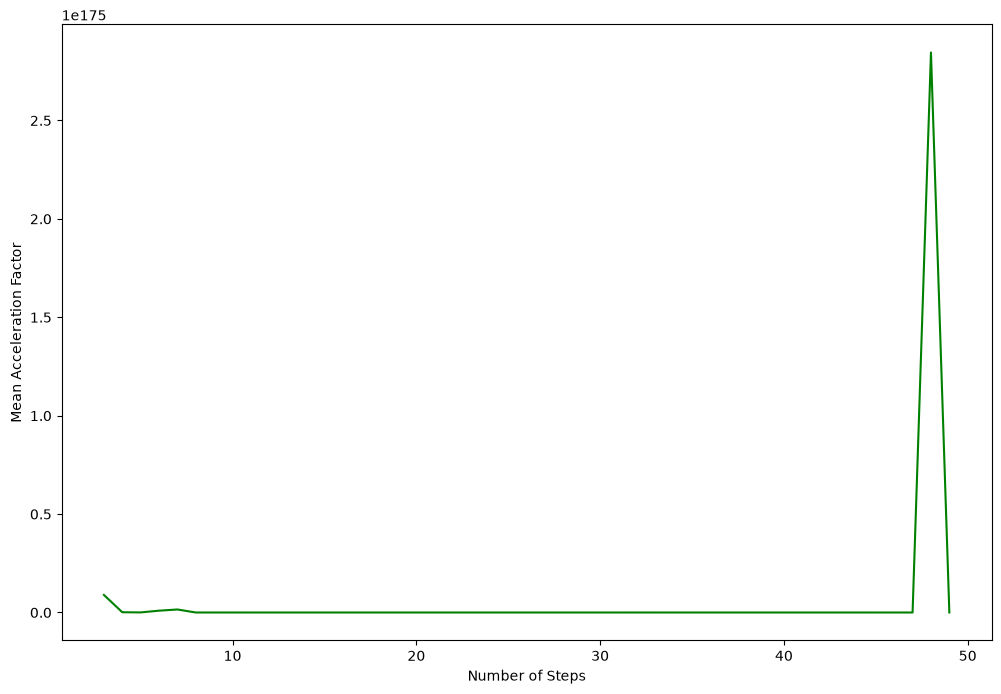

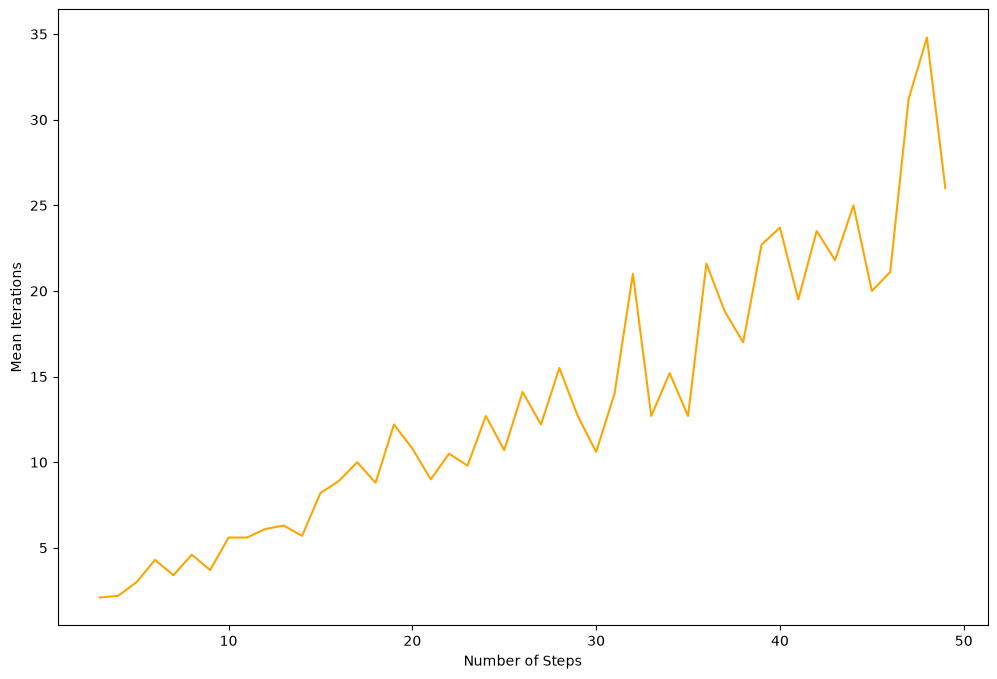

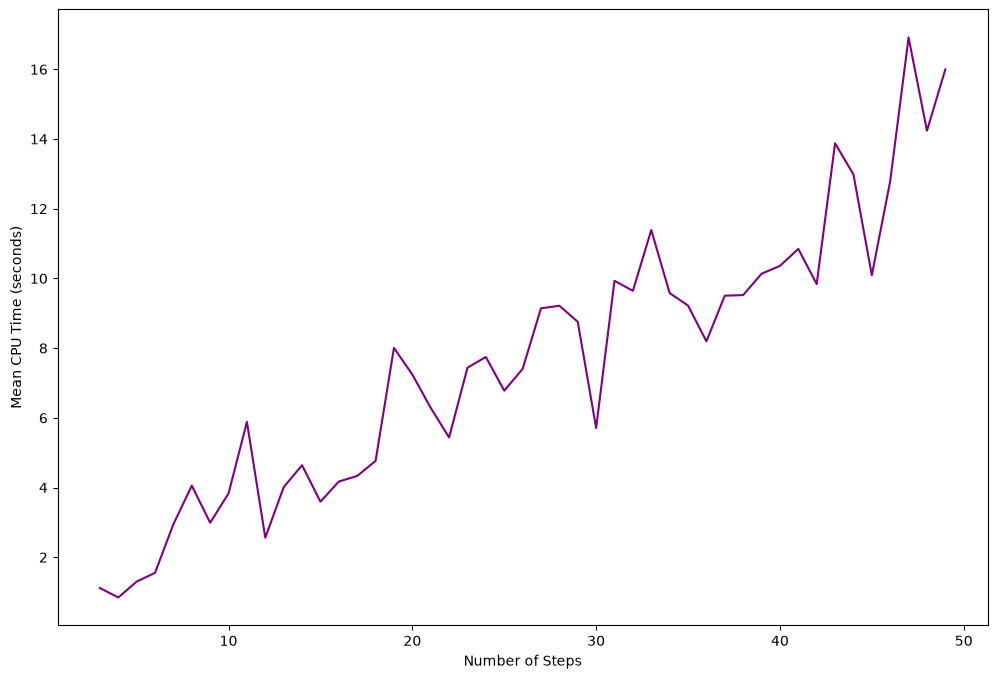

----------- STANDARD DEVIATION ANALYSIS -----------


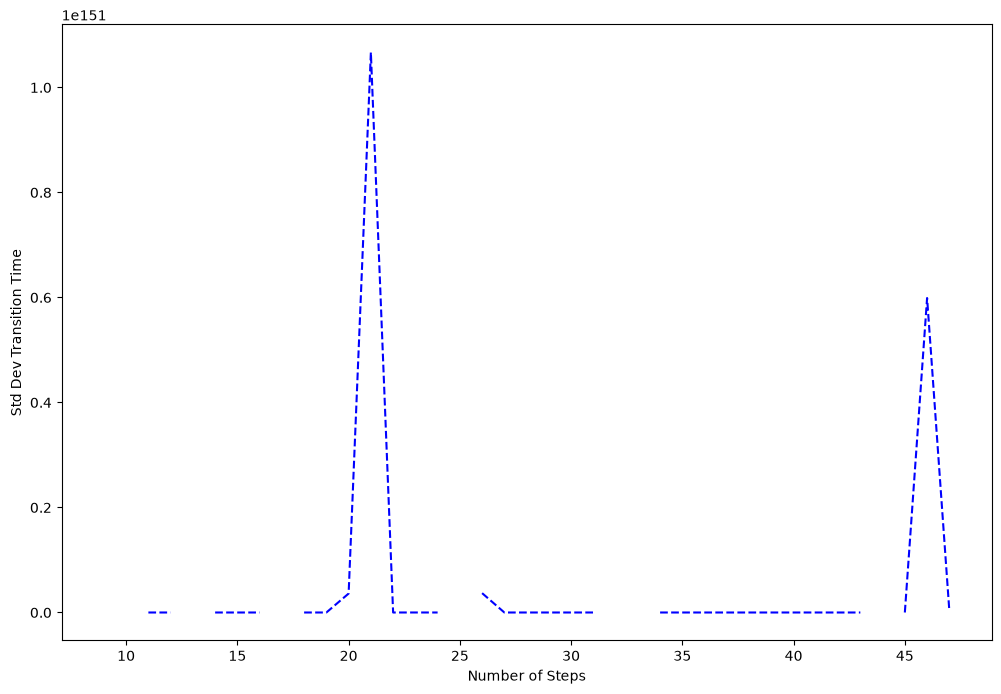

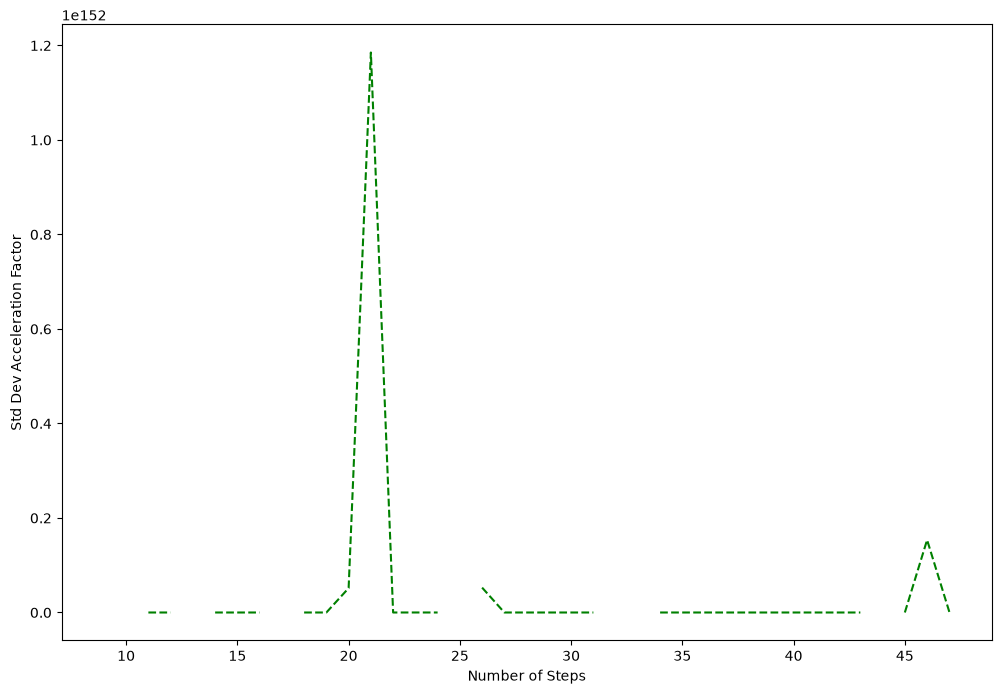

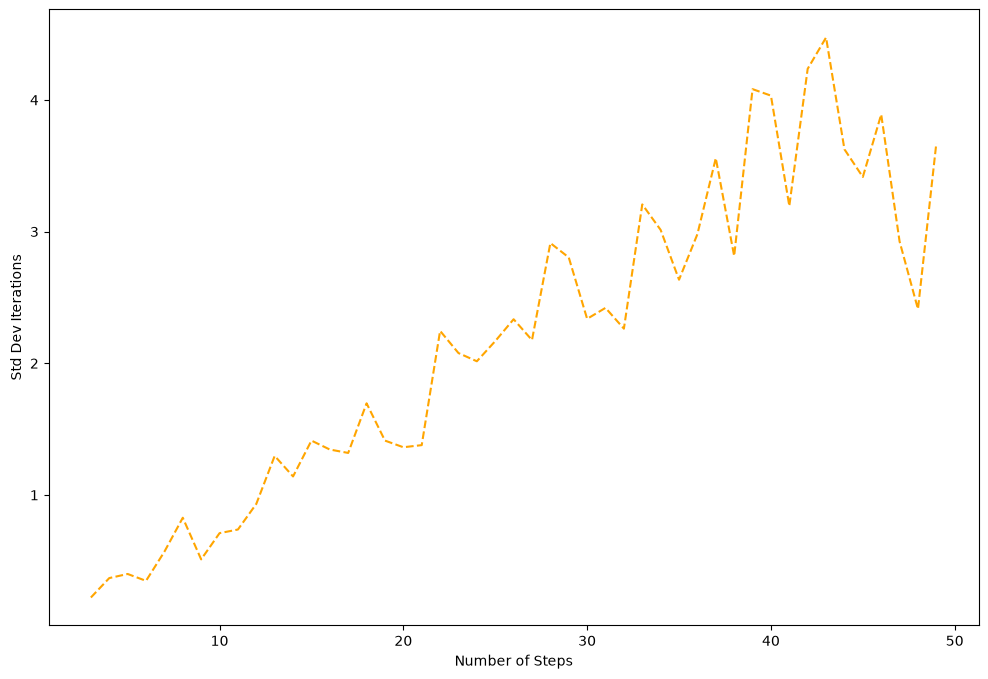

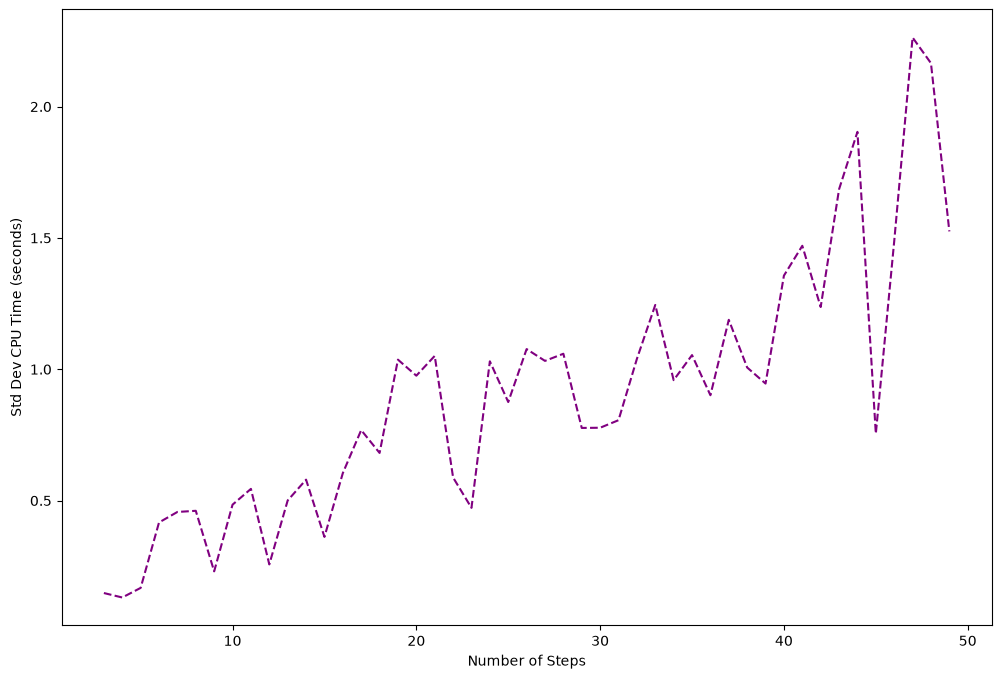

In [35]:
num_steps_axis = np.arange(3, 50, 1)
mean_transition_times = []
mean_acceleration_factors = []
mean_iterations = []
mean_cpu_times = []
dev_transition_times = []
dev_acceleration_factors = []
dev_iterations = []
dev_cpu_times = []

for num_steps in tqdm(num_steps_axis, desc="Number of Steps"):
    transition_times = []
    acceleration_factors = []
    iterations = []
    cpu_times = []

    results = Parallel(n_jobs=-1)(
        delayed(run_one_simulation)(num_steps=num_steps, W=0.5, sigma=0.1)
        for _ in range(10)
    )

    for transition_time, acc_factor, simulation_time, cpu_time in results:
        if transition_time is not None:
            transition_times.append(transition_time)
            acceleration_factors.append(acc_factor)
            iterations.append(simulation_time)
            cpu_times.append(cpu_time)

    transition_times = np.array(transition_times)
    acceleration_factors = np.array(acceleration_factors)
    iterations = np.array(iterations)
    cpu_times = np.array(cpu_times)

    mean_transition_time = np.mean(transition_times)
    mean_acceleration_factor = np.mean(acceleration_factors)
    mean_iteration = np.mean(iterations)
    mean_cpu_time = np.mean(cpu_times)

    dev_transition_time = np.std(transition_times)
    dev_acceleration_factor = np.std(acceleration_factors)
    dev_iteration = np.std(iterations)
    dev_cpu_time = np.std(cpu_times)

    mean_transition_times.append(mean_transition_time)
    mean_acceleration_factors.append(mean_acceleration_factor)
    mean_iterations.append(mean_iteration)
    mean_cpu_times.append(mean_cpu_time)
    dev_transition_times.append(dev_transition_time / np.sqrt(len(transition_times)))  # Standard error of the mean
    dev_acceleration_factors.append(dev_acceleration_factor / np.sqrt(len(acceleration_factors)))   # Standard error of the mean
    dev_iterations.append(dev_iteration / np.sqrt(len(iterations)))   # Standard error of the mean
    dev_cpu_times.append(dev_cpu_time / np.sqrt(len(cpu_times)))   # Standard error of the mean

print('----------- MEAN ANALYSIS -----------')

plt.figure(figsize=(12, 8))
plt.xlabel('Number of Steps')
plt.ylabel('Mean Transition Time')
plt.plot(num_steps_axis, mean_transition_times, label='Mean Transition Time', color='blue')
plt.show()

plt.figure(figsize=(12, 8))
plt.xlabel('Number of Steps')
plt.ylabel('Mean Acceleration Factor')
plt.plot(num_steps_axis, mean_acceleration_factors, label='Mean Acceleration Factor', color='green')
plt.show()

plt.figure(figsize=(12, 8))
plt.xlabel('Number of Steps')
plt.ylabel('Mean Iterations')
plt.plot(num_steps_axis, mean_iterations, label='Mean Iterations', color='orange')
plt.show()

plt.figure(figsize=(12, 8))
plt.xlabel('Number of Steps')
plt.ylabel('Mean CPU Time (seconds)')
plt.plot(num_steps_axis, mean_cpu_times, label='Mean CPU Time', color='purple')
plt.show()

print('----------- STANDARD DEVIATION ANALYSIS -----------')

plt.figure(figsize=(12, 8))
plt.xlabel('Number of Steps')
plt.ylabel('Std Dev Transition Time')
plt.plot(num_steps_axis, dev_transition_times, label='Std Dev Transition Time', color='blue', linestyle='--')
plt.show()

plt.figure(figsize=(12, 8))
plt.xlabel('Number of Steps')
plt.ylabel('Std Dev Acceleration Factor')
plt.plot(num_steps_axis, dev_acceleration_factors, label='Std Dev Acceleration Factor', color='green', linestyle='--')
plt.show()

plt.figure(figsize=(12, 8))
plt.xlabel('Number of Steps')
plt.ylabel('Std Dev Iterations')
plt.plot(num_steps_axis, dev_iterations, label='Std Dev Iterations', color='orange', linestyle='--')
plt.show()

plt.figure(figsize=(12, 8))
plt.xlabel('Number of Steps')
plt.ylabel('Std Dev CPU Time (seconds)')
plt.plot(num_steps_axis, dev_cpu_times, label='Std Dev CPU Time', color='purple', linestyle='--')
plt.show()

## Section 5

Further exploration on the influence of standard deviation of the gaussian over the results obtained

In [ ]:
import numpy as np
from stage_escape.abp_abf.potential import Potential
from stage_escape.abp_abf.transition_detector import TransitionDetector
from stage_escape.abp_abf.abp_metadynamics import ABPMetaDynamics
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from tqdm.notebook import tqdm


def run_one_simulation(num_steps, W, sigma):
    dt = 0.01
    potential = Potential(2, lambda x: entropic_switch(x[0], x[1]), lambda x: grad_entropic_switch(x[0], x[1]))


    abp = ABPMetaDynamics(num_steps=num_steps, td=TransitionDetector(np.array([]), lambda x: -(x[0] - 1) ** 2 - x[1] ** 2, -1 / 4), delta_t=dt, dimension=2, D=1, initial_position=np.array([-1.0, 0.0]), b=potential, W=W, sigma=sigma)
    transition_time, simulation_time = abp.simulate()

    return transition_time, transition_time /simulation_time, simulation_time / dt

In [ ]:
sigma_axis = np.logspace(np.log10(0.00001), np.log10(0.5), num=30, endpoint=True)
mean_transition_times = []
mean_acceleration_factors = []
mean_iterations = []
dev_transition_times = []
dev_acceleration_factors = []
dev_iterations = []

for sigma in tqdm(sigma_axis, desc="Sigma values"):
    transition_times = []
    acceleration_factors = []
    iterations = []

    results = Parallel(n_jobs=-1)(
        delayed(run_one_simulation)(num_steps=10, W=0.3, sigma=sigma)
        for _ in range(10)
    )

    for transition_time, acc_factor, simulation_time in results:
        if transition_time is not None:
            transition_times.append(transition_time)
            acceleration_factors.append(acc_factor)
            iterations.append(simulation_time)

    transition_times = np.array(transition_times)
    acceleration_factors = np.array(acceleration_factors)
    iterations = np.array(iterations)

    mean_transition_time = np.mean(transition_times)
    mean_acceleration_factor = np.mean(acceleration_factors)
    mean_iteration = np.mean(iterations)

    dev_transition_time = np.std(transition_times)
    dev_acceleration_factor = np.std(acceleration_factors)
    dev_iteration = np.std(iterations)

    mean_transition_times.append(mean_transition_time)
    mean_acceleration_factors.append(mean_acceleration_factor)
    mean_iterations.append(mean_iteration)
    dev_transition_times.append(dev_transition_time / np.sqrt(len(transition_times)))  # Standard error of the mean
    dev_acceleration_factors.append(dev_acceleration_factor / np.sqrt(len(acceleration_factors)))   # Standard error of the mean
    dev_iterations.append(dev_iteration / np.sqrt(len(iterations)))   # Standard error of the mean


plt.figure(figsize=(12, 8))
plt.xlabel('Sigma')
plt.ylabel('Mean Transition Time')
plt.plot(np.log10(sigma_axis), mean_transition_times, label='Mean Transition Time', color='blue')
plt.show()

plt.figure(figsize=(12, 8))
plt.xlabel('Sigma')
plt.ylabel('Mean Acceleration Factor')
plt.plot(np.log10(sigma_axis), mean_acceleration_factors, label='Mean Acceleration Factor', color='green')
plt.show()

plt.figure(figsize=(12, 8))
plt.xlabel('Sigma')
plt.ylabel('Mean Iterations')
plt.plot(np.log10(sigma_axis), mean_iterations, label='Mean Iterations', color='orange')
plt.show()

plt.figure(figsize=(12, 8))
plt.xlabel('Sigma')
plt.ylabel('Std Dev Transition Time')
plt.plot(np.log10(sigma_axis), dev_transition_times, label='Std Dev Transition Time', color='blue', linestyle='--')
plt.show()

plt.figure(figsize=(12, 8))
plt.xlabel('Sigma')
plt.ylabel('Std Dev Acceleration Factor')
plt.plot(np.log10(sigma_axis), dev_acceleration_factors, label='Std Dev Acceleration Factor', color='green', linestyle='--')
plt.show()

plt.figure(figsize=(12, 8))
plt.xlabel('Sigma')
plt.ylabel('Std Dev Iterations')
plt.plot(np.log10(sigma_axis), dev_iterations, label='Std Dev Iterations', color='orange', linestyle='--')
plt.show()

Sigma values:   0%|          | 0/30 [00:00<?, ?it/s]

KeyboardInterrupt: 